#  ReelShort データ分析ノートブック

## 使用データについて

本分析では以下のデータを使用しています：

### データソース
| データ | ファイル | 内容 |
|--------|----------|------|
| 日本語版 ReelShort | `all_movies_basic.json` | 日本語版アプリの全1,026作品 |
| 英語版 ReelShort | `all_movies_english_full.json` | 英語版アプリの全1,827作品 |

### 日本語版データの内訳（制作国別）

日本語版ReelShortの1,026作品は、以下のように分類されます：

| 制作国 | 作品数 | 説明 |
|--------|--------|------|
| **RSオリジナル日本** | 17作品 | ReelShortが日本で制作したオリジナルドラマ |
| **アメリカ制作** | 352作品 | 英語版オリジナルを日本語吹き替え |
| **中国制作** | 518作品 | 中国語版オリジナルを日本語吹き替え |
| **タイ制作** | 97作品 | タイ語版オリジナルを日本語吹き替え |
| **その他** | 42作品 | その他アジア地域制作の吹き替え |

### 制作国の判別方法
- `t_book_id`（作品ID）の接頭辞パターンで判別
  - `140000000140000...` → 日本オリジナル
  - `1400...` → アメリカ制作
  - `1490...` → 中国制作
  - `1480...` → タイ制作

### 注意事項
- 「日本語版」≠「日本制作」です
- 日本語版の大半（約98%）は海外制作の吹き替え版です
- 本分析では制作国別に収益性を比較しています


In [340]:
# =============================================
#  初回セットアップ（必要なパッケージのインストール）
# =============================================
# 初回のみ実行してください。2回目以降はスキップしてOKです。

import subprocess
import sys

def install_packages():
    packages = ['pandas', 'numpy', 'matplotlib', 'plotly', 'wordcloud', 'openpyxl']
    for pkg in packages:
        try:
            __import__(pkg)
            print(f" {pkg} - インストール済み")
        except ImportError:
            print(f" {pkg} をインストール中...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
            print(f" {pkg} - インストール完了")


# install_packages()

## 1. データ読み込みと前処理

### 使用データ
- **メインデータ**: 日本語版ReelShort全作品（`all_movies_basic.json`）
- **比較用データ**: 英語版ReelShort全作品（`all_movies_english_full.json`）

### データの取得方法
- ReelShort APIから取得（2024年12月時点）
- 作品情報（タイトル、再生数、いいね数、公開日など）を含む

### 変数名の規則
| 変数名 | 内容 |
|--------|------|
| `df` | 日本語版全作品のDataFrame |
| `df_en` | 英語版全作品のDataFrame |
| `df_ja` | 日本語版のみ（df と同じ） |


In [341]:
# 必要なライブラリのインポート
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
plt.rcParams['font.family'] = ['DejaVu Sans', 'Noto Sans CJK JP', 'IPAGothic']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# Plotly（インタラクティブグラフ用）
try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
    # GitHub Pages用: HTMLに埋め込み可能な形式で出力
    pio.renderers.default = 'notebook'
    pio.templates.default = 'plotly_white' 
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
    print(" Plotly利用可能 - インタラクティブグラフが使えます")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("⚠️ Plotlyがインストールされていません。pip install plotly でインストールしてください")

print("ライブラリ読み込み完了！")


 Plotly利用可能 - インタラクティブグラフが使えます
ライブラリ読み込み完了！


In [342]:
# ヘルパー関数
def objectid_to_datetime(oid):
    """MongoDB ObjectIdから作成日時を抽出"""
    if not oid or len(oid) < 8:
        return None
    try:
        timestamp = int(oid[:8], 16)
        return datetime.fromtimestamp(timestamp)
    except:
        return None

def format_number(num):
    """数値をK/M形式でフォーマット"""
    if num >= 1000000:
        return f"{num/1000000:.1f}M"
    elif num >= 1000:
        return f"{num/1000:.1f}K"
    return str(num)

def get_category(t_book_id):
    """t_book_idからカテゴリを判定"""
    if not t_book_id:
        return "不明"
    prefix = t_book_id[:15] if len(t_book_id) >= 15 else t_book_id
    categories = {
        "149000000000000": "英語圏オリジナル",
        "140000000000000": "日本語吹き替え版",
        "149000000000002": "英語圏（シリーズ2）",
        "148000000000000": "中国語圏",
        "149000000000001": "英語圏（シリーズ1）",
        "140000200000000": "日本向けローカライズ",
        "140000000140000": "日本人キャスト",
        "149001000000000": "英語圏（プレミアム）",
        "142600000000002": "スペイン語圏",
        "142600000000000": "スペイン語圏",
        "140000000000002": "日本向け（シリーズ2）",
        "140001000000000": "日本向け（プレミアム）",
        "141000000000000": "韓国語圏",
    }
    return categories.get(prefix, "その他")

def get_region(t_book_id):
    """t_book_idから地域を判定"""
    if not t_book_id:
        return "不明"
    prefix3 = t_book_id[:3] if len(t_book_id) >= 3 else ""
    regions = {
        "149": "英語圏（アメリカ等）",
        "140": "日本",
        "148": "中国語圏",
        "142": "スペイン語圏",
        "141": "韓国語圏",
    }
    return regions.get(prefix3, "その他")

print("ヘルパー関数定義完了！")


ヘルパー関数定義完了！


In [343]:
# データ読み込み
with open('../data/all_movies_basic.json', 'r', encoding='utf-8') as f:
    all_movies = json.load(f)

print(f" 読み込んだ作品数: {len(all_movies)}")

# DataFrameに変換
data = []
for m in all_movies:
    oid = m.get('_id') or m.get('book_id')
    release_dt = objectid_to_datetime(oid)
    t_book_id = m.get('t_book_id', '')
    
    data.append({
        'book_id': m.get('book_id', ''),
        't_book_id': t_book_id,
        'title': m.get('book_title', ''),
        'read_count': m.get('read_count', 0),
        'collect_count': m.get('collect_count', 0),
        'chapter_count': m.get('chapter_count', 0),
        'release_date': release_dt,
        'special_desc': m.get('special_desc', ''),
        'tags': m.get('tag', []),
        'category': get_category(t_book_id),
        'region': get_region(t_book_id),
        'is_japanese_cast': t_book_id.startswith('140000000140000')
    })

df = pd.DataFrame(data)

# 追加の列を作成
df['year_month'] = df['release_date'].apply(lambda x: x.strftime('%Y-%m') if x else None)
df['year'] = df['release_date'].apply(lambda x: x.year if x else None)
df['month'] = df['release_date'].apply(lambda x: x.month if x else None)
df['read_count_log'] = np.log10(df['read_count'].replace(0, 1))

print(f" DataFrame作成完了: {df.shape[0]}行 x {df.shape[1]}列")
df.head()


 読み込んだ作品数: 1026
 DataFrame作成完了: 1026行 x 16列


,book_id,t_book_id,title,read_count,collect_count,chapter_count,release_date,special_desc,tags,category,region,is_japanese_cast,year_month,year,month,read_count_log
0,6901b1f0e12f46f83f05026d,140000000000000355,おかえりパパとママだよ,39454,673,27,2025-10-29 15:19:28,大学一年生の娘が、家族恒例の感謝祭を祝うために久しぶりに帰省する。\nしかし、彼女は両親の様...,[サスペンス],日本語吹き替え版,日本,False,2025-10,2025,10,4.596091
1,6854d0b61cc7f0fc460aa3a1,140000000000000272,人を呪わば穴二つ,589496,41038,30,2025-06-20 12:08:38,専業主婦カレン、夫のトムはお金持ちの弁護士だった。ある日カレンが外出中、自宅が火災に遭い、5...,"[女性向けのドラマ, ドラマ, 復讐, 浮気, 隣人, 家庭主婦]",日本語吹き替え版,日本,False,2025-06,2025,6,5.770481
2,684a3c59bf0dba6aa601c07a,140000000000000257,調停者,291720,25645,38,2025-06-12 11:32:57,妹が保険を失い命を落としたその日から、マッテオ・レオーネの人生は一変した。絶望の中で、彼は保...,"[男向けのドラマ, 復讐, モダン, 守る夫, 医者]",日本語吹き替え版,日本,False,2025-06,2025,6,5.464966
3,686f5afe374f7f776f0f5956,140000000000000279,空飛ぶ修羅場,3768813,86860,41,2025-07-10 15:17:34,足を骨折しギプスを装着中のイヴは、ハワイで行われる兄の結婚式に出席するため、広めの座席を予約...,[復讐],日本語吹き替え版,日本,False,2025-07,2025,7,6.576205
4,68d2060f4d6ba943670b0645,140000000000000334,偽りのルナと運命のつがい,37896,488,44,2025-09-23 11:29:35,彼は彼女を救うため、残忍な父を殺した。新たなアルファキングとなった彼は、運命のメイトを生かす...,[復讐],日本語吹き替え版,日本,False,2025-09,2025,9,4.578593


## 2. 基本統計

### 対象データ
**日本語版ReelShort 全1,026作品**

このセクションでは日本語版アプリに配信されている全作品の基本統計を表示します。
（制作国は問わず、日本語版に存在する全ての作品が対象）


In [344]:
# 基本統計情報
print("=" * 60)
print(" 基本統計情報")
print("=" * 60)

stats = {
    '総作品数': len(df),
    '総再生数': df['read_count'].sum(),
    '総いいね数': df['collect_count'].sum(),
    '平均再生数': df['read_count'].mean(),
    '中央値再生数': df['read_count'].median(),
    '最大再生数': df['read_count'].max(),
    '平均エピソード数': df['chapter_count'].mean(),
    '日本人キャスト作品数': df['is_japanese_cast'].sum(),
}

for key, val in stats.items():
    print(f"  {key}: {format_number(int(val))} ({int(val):,})")

# 最も再生された作品TOP5
print("\n 再生数TOP5:")
top5 = df.nlargest(5, 'read_count')[['title', 'read_count', 'category']]
for _, row in top5.iterrows():
    print(f"  {format_number(row['read_count']):>8} | {row['title']} ({row['category']})")


 基本統計情報
  総作品数: 1.0K (1,026)
  総再生数: 1436.1M (1,436,146,756)
  総いいね数: 18.4M (18,402,161)
  平均再生数: 1.4M (1,399,753)
  中央値再生数: 492.4K (492,423)
  最大再生数: 21.7M (21,710,063)
  平均エピソード数: 70 (70)
  日本人キャスト作品数: 17 (17)

 再生数TOP5:
     21.7M | ［吹き替え］私こそが学園のクイーン・ビー (日本向け（プレミアム）)
     20.5M | あなたと出会う運命 (日本語吹き替え版)
     17.7M | 私こそが学園のクイーン・ビー (日本語吹き替え版)
     17.7M | 労働者父が大富豪？！ (中国語圏)
     16.5M | ホームレスの夫が実は大富豪 ～クリスマスの奇跡～ (日本語吹き替え版)


## 3. 再生数分析

### 対象データ
**日本語版ReelShort 全1,026作品**

再生数の分布、トップ作品などを分析します。


In [345]:
#  再生数 vs 公開日 の散布図（Plotly）

df_plot = df[df['release_date'].notna()].copy()

fig = px.scatter(
    df_plot,
    x='release_date',
    y='read_count',
    color='region',
    size='chapter_count',
    size_max=20,
    hover_name='title',
    hover_data={
        'read_count': ':,',
        'collect_count': ':,',
        'category': True,
        'chapter_count': True
    },
    title='日本語のReelShortドラマ、公開日×再生数の分布',
    log_y=True,
    labels={
        'read_count': '再生数',
        'release_date': '公開日',
        'region': '地域',
        'collect_count': 'いいね数',
        'category': 'カテゴリ',
        'chapter_count': 'EP数'
    }
)

fig.update_layout(
    height=600,width=1200,
    hovermode='closest',
    template='plotly_white'
)

fig.show()


## 4. 地域・カテゴリ分析


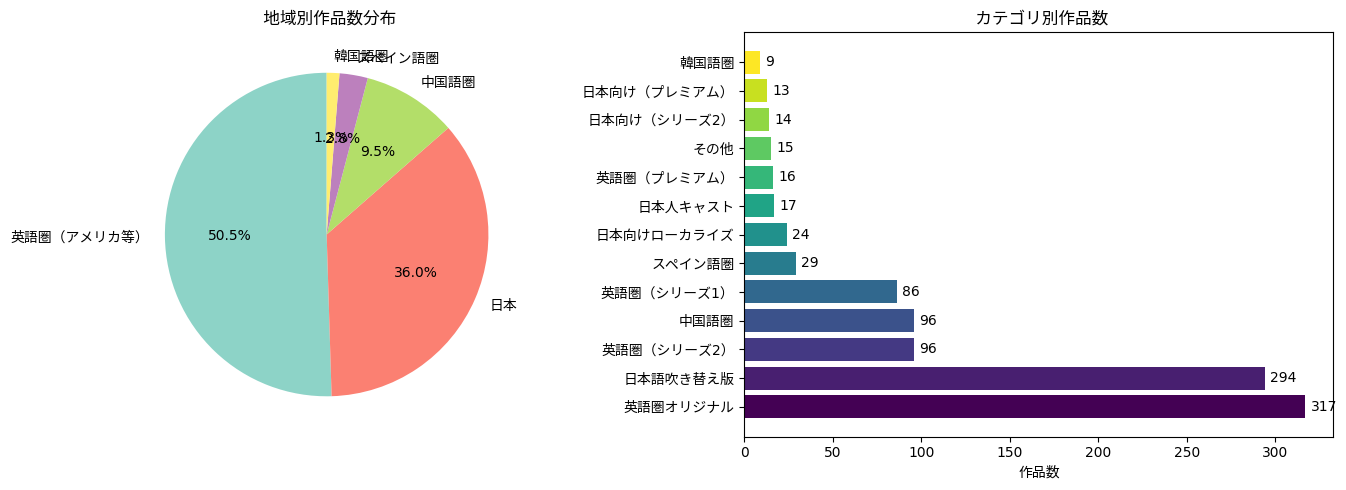

In [346]:
# 地域別・カテゴリ別の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 地域別作品数（円グラフ）
region_counts = df['region'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(region_counts)))
axes[0].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title(' 地域別作品数分布')

# 右: カテゴリ別作品数（横棒グラフ）
category_counts = df['category'].value_counts()
y_pos = np.arange(len(category_counts))
bars = axes[1].barh(y_pos, category_counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(category_counts))))
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(category_counts.index)
axes[1].set_xlabel('作品数')
axes[1].set_title(' カテゴリ別作品数')
for i, (count, bar) in enumerate(zip(category_counts.values, bars)):
    axes[1].text(count + 3, i, str(count), va='center')

plt.tight_layout()
plt.show()


## 5. 時系列分析


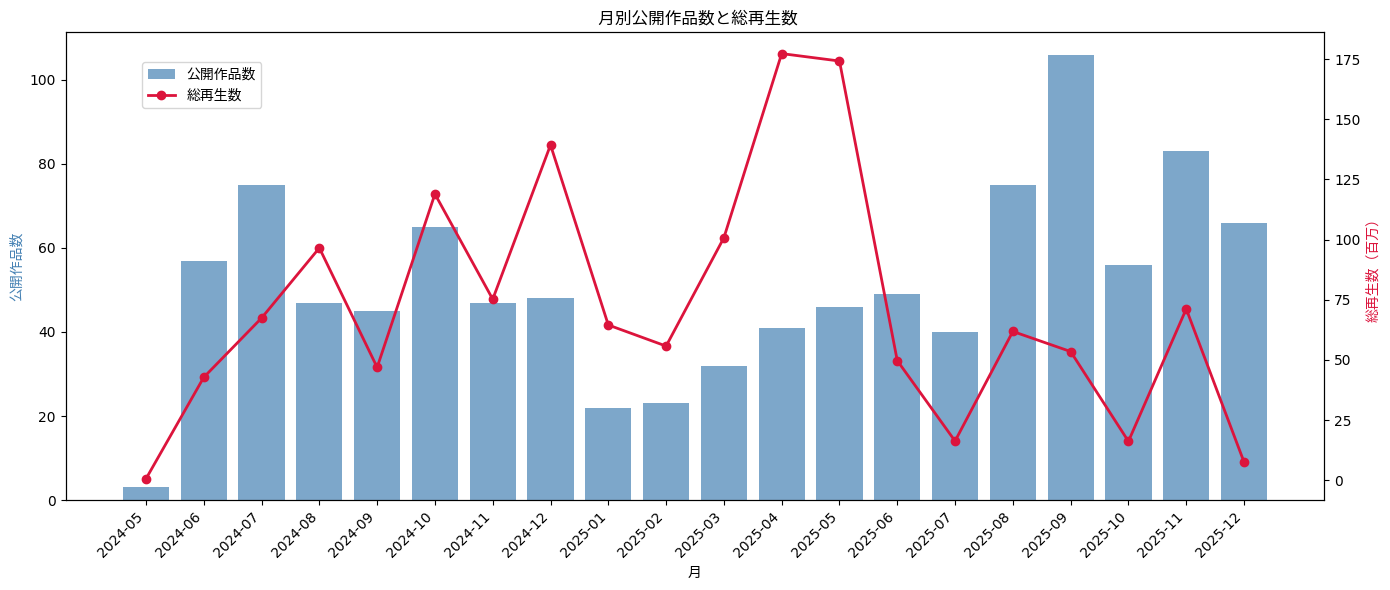

In [347]:
# 月別公開数と累積再生数
df_time = df[df['year_month'].notna()].copy()
monthly = df_time.groupby('year_month').agg({
    'book_id': 'count',
    'read_count': 'sum'
}).rename(columns={'book_id': 'releases', 'read_count': 'total_reads'})

fig, ax1 = plt.subplots(figsize=(14, 6))

# 棒グラフ: 公開数
ax1.bar(range(len(monthly)), monthly['releases'], color='steelblue', alpha=0.7, label='公開作品数')
ax1.set_xlabel('月')
ax1.set_ylabel('公開作品数', color='steelblue')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly.index, rotation=45, ha='right')

# 折れ線グラフ: 再生数
ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['total_reads'] / 1e6, color='crimson', linewidth=2, marker='o', label='総再生数')
ax2.set_ylabel('総再生数（百万）', color='crimson')

plt.title(' 月別公開作品数と総再生数')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()


## 6. 日本人キャスト作品分析 

### 対象データ
**日本語版の中の「RSオリジナル日本ドラマ」17作品のみ**

ここでは、日本で撮影・制作されたReelShortオリジナル作品のみを分析します。

### 判別方法
- `t_book_id`が`140000000140000`で始まる作品
- 日本人キャストによる日本語オリジナル作品

### 他との違い
| 分類 | 説明 |
|------|------|
| RSオリジナル日本（17作品） | 日本で制作されたオリジナル ← **このセクションの対象** |
| アメリカ制作吹き替え（352作品） | 英語版を日本語に吹き替え |
| 中国制作吹き替え（518作品） | 中国語版を日本語に吹き替え |


In [348]:
# 日本人キャスト作品のみ抽出
jp_cast = df[df['is_japanese_cast']].copy()
jp_cast = jp_cast.sort_values('read_count', ascending=False)
jp_cast['rank'] = range(1, len(jp_cast) + 1)

print(f" 日本人キャスト日本オリジナル作品: {len(jp_cast)}作品")
print(f"   総再生数: {format_number(jp_cast['read_count'].sum())}")
print(f"   平均再生数: {format_number(int(jp_cast['read_count'].mean()))}")
print()

# ランキング表示
print("【再生数ランキング】")
print("-" * 70)
for _, row in jp_cast.iterrows():
    date = row['release_date'].strftime('%Y-%m-%d') if row['release_date'] else '不明'
    print(f"{row['rank']:2}. {format_number(row['read_count']):>8} | {row['title'][:35]:<35} | {date}")


 日本人キャスト日本オリジナル作品: 17作品
   総再生数: 94.7M
   平均再生数: 5.6M

【再生数ランキング】
----------------------------------------------------------------------
 1.    14.3M | 令嬢決戦！私こそが学園のクイーン                    | 2025-04-16
 2.    11.6M | ダイヤモンドの再会                           | 2024-12-03
 3.    10.9M | 冷酷御曹司の愛妻計画                          | 2025-04-25
 4.    10.7M | 財閥令嬢様の二重生活                          | 2024-12-10
 5.     9.0M | 嫌いなアイツの専属メイド!?                      | 2025-05-20
 6.     8.4M | 銃と金とクリスマス                           | 2025-05-09
 7.     6.7M | せめて最後に愛のキスを                         | 2025-01-13
 8.     5.3M | 無職の夫は大富豪だった件!                       | 2025-03-14
 9.     3.8M | 消防士の元夫、悔恨の炎に焼かれて                    | 2025-06-30
10.     3.3M | 帰ってきたお嬢様                            | 2025-01-13
11.     2.2M | 一目惚れ！今すぐ結婚してくれますか？                  | 2025-04-08
12.     2.1M | ケーキ職人のワタシが大富豪と偽装結婚した話               | 2025-04-16
13.     1.8M | もう一度、君に恋をする                         | 2025-04-12
14.     1.5M | 負け犬の私がバージンを捨てる！ 

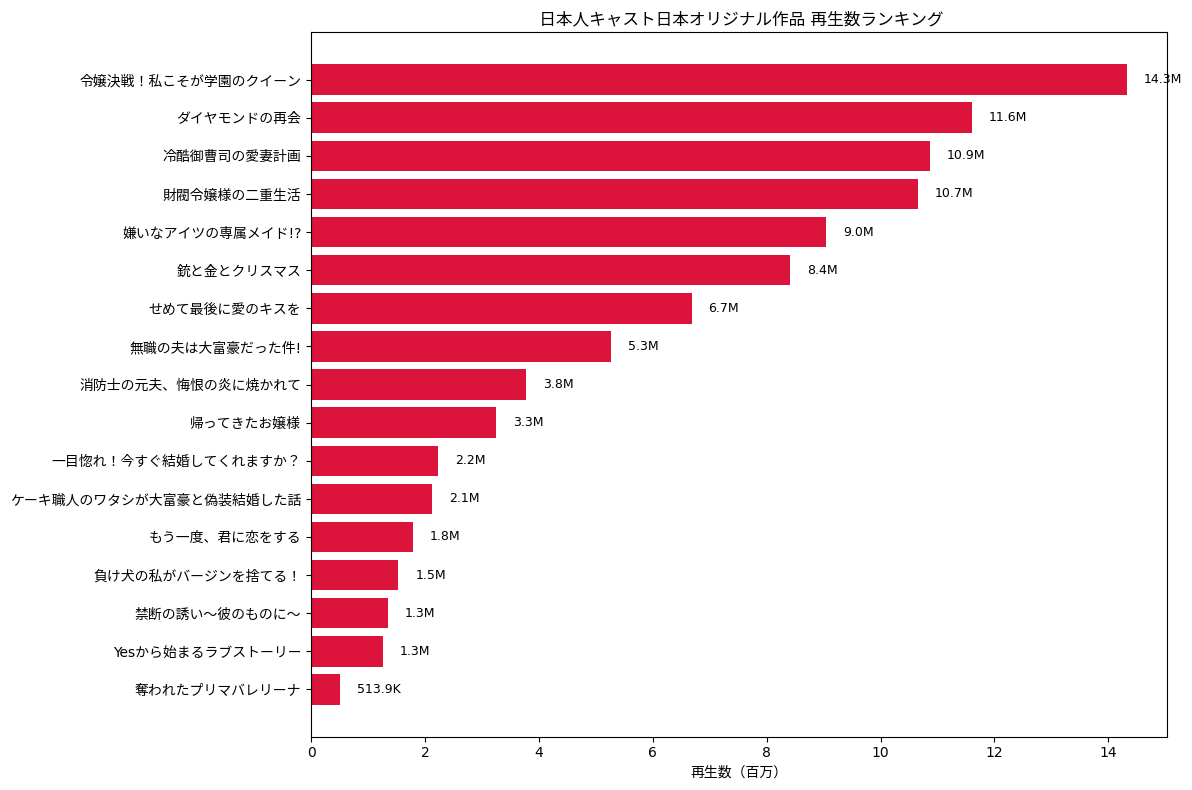

In [349]:
# 日本人キャスト作品の再生数ランキング（横棒グラフ）
jp_sorted = jp_cast.sort_values('read_count', ascending=True)

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(jp_sorted))
bars = plt.barh(y_pos, jp_sorted['read_count'] / 1e6, color='crimson')
plt.yticks(y_pos, [t[:25] + '...' if len(t) > 25 else t for t in jp_sorted['title']])
plt.xlabel('再生数（百万）')
plt.title(' 日本人キャスト日本オリジナル作品 再生数ランキング')

for bar, val in zip(bars, jp_sorted['read_count']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             format_number(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 7. タグ分析


 ユニークタグ数: 202


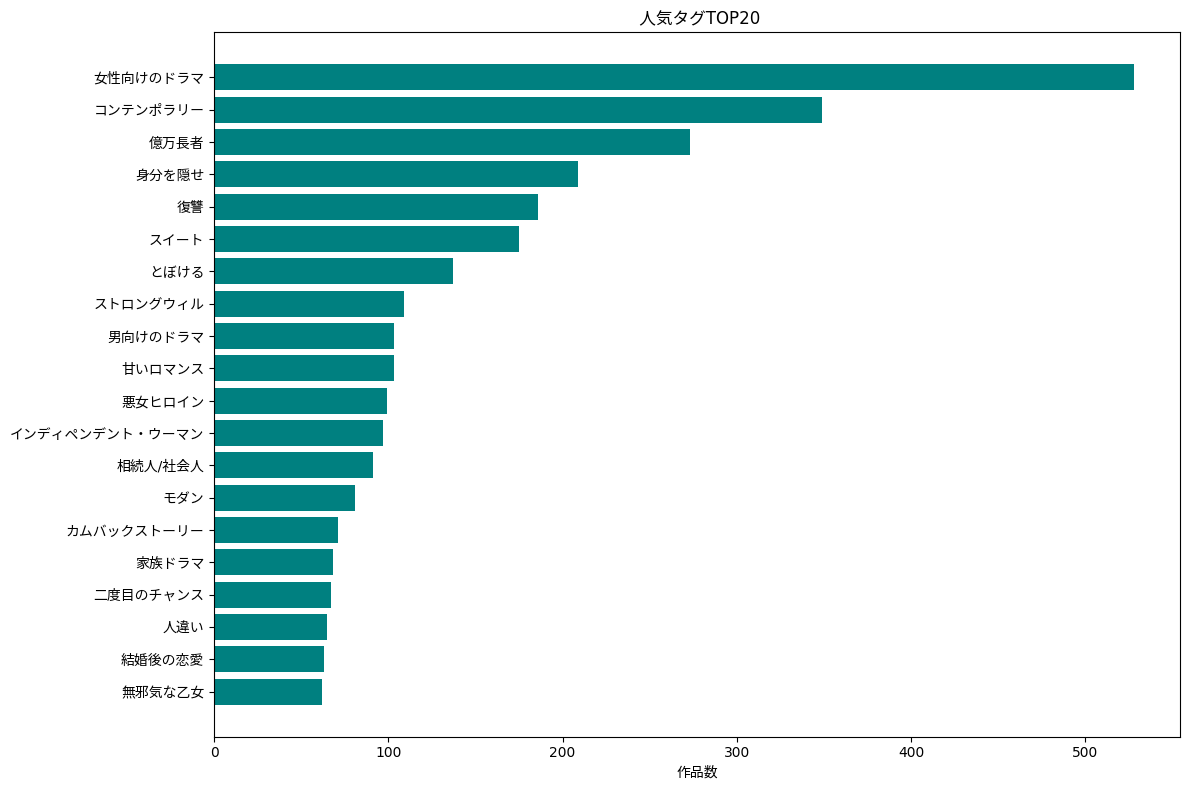

In [350]:
# タグの集計
all_tags = []
for tags in df['tags']:
    if isinstance(tags, list):
        all_tags.extend(tags)

tag_counts = Counter(all_tags)
print(f" ユニークタグ数: {len(tag_counts)}")

# TOP20タグ
top_tags = dict(sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_tags))
plt.barh(y_pos, list(top_tags.values()), color='teal')
plt.yticks(y_pos, list(top_tags.keys()))
plt.xlabel('作品数')
plt.title(' 人気タグTOP20')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 8. ワードクラウド


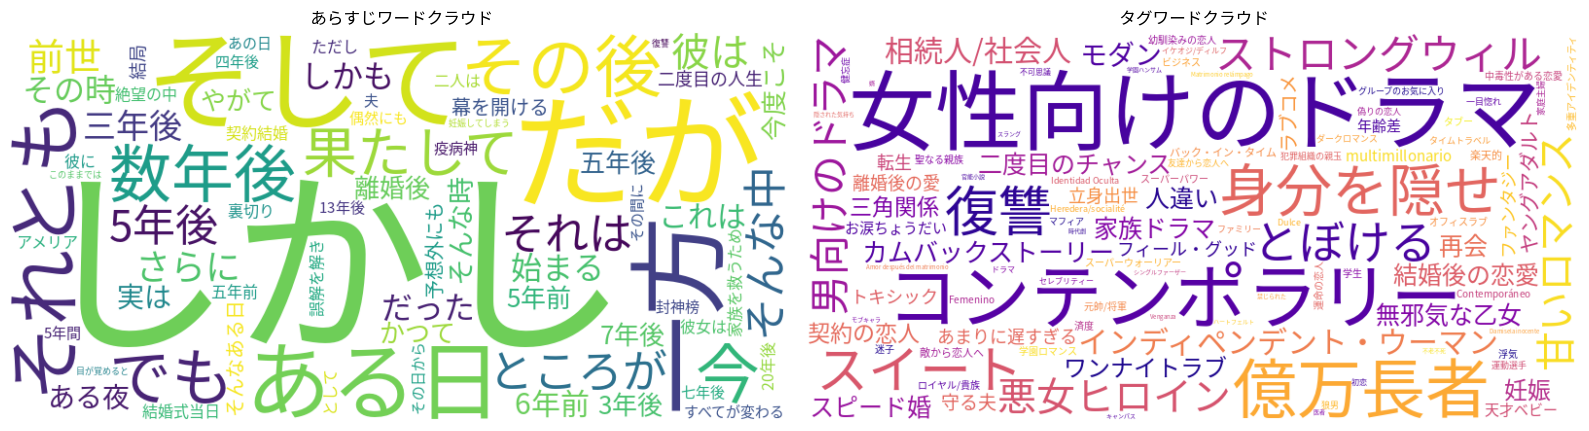

In [351]:
# ワードクラウド生成
try:
    from wordcloud import WordCloud
    import os
    
    # 日本語フォントパス
    font_paths = [
        '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'
    ]
    font_path = None
    for fp in font_paths:
        if os.path.exists(fp):
            font_path = fp
            break
    
    # ストップワード
    stopwords = {'の', 'に', 'は', 'を', 'た', 'が', 'で', 'て', 'と', 'し', 'れ', 'さ', 'ある', 
                 'いる', 'も', 'な', 'こと', 'い', 'や', 'など', 'その', 'から', 'する', 'ない',
                 'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has',
                 'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from', 'and', 'or'}
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左: あらすじワードクラウド
    all_desc = ' '.join(df['special_desc'].dropna().tolist())
    wc1 = WordCloud(width=800, height=400, background_color='white', max_words=150,
                    stopwords=stopwords, font_path=font_path, colormap='viridis')
    wc1.generate(all_desc)
    axes[0].imshow(wc1, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title(' あらすじワードクラウド')
    
    # 右: タグワードクラウド
    wc2 = WordCloud(width=800, height=400, background_color='white', max_words=100,
                    font_path=font_path, colormap='plasma')
    wc2.generate_from_frequencies(tag_counts)
    axes[1].imshow(wc2, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('️ タグワードクラウド')
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️ wordcloudがインストールされていません。pip install wordcloud でインストールしてください")


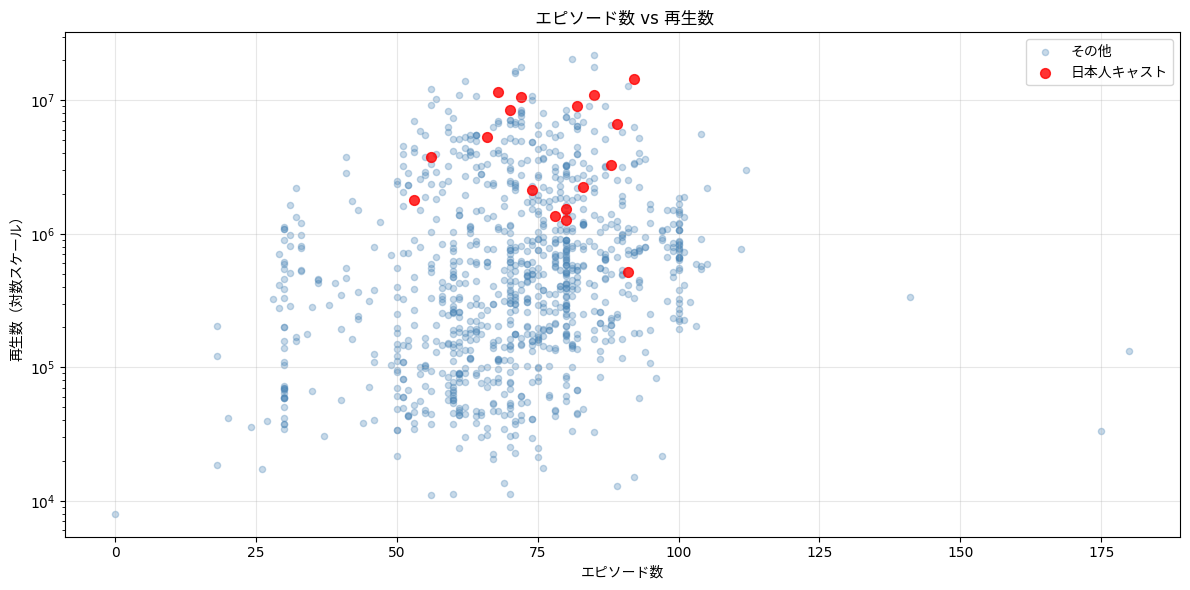


相関係数:
  再生数 vs エピソード数: 0.087
  再生数 vs いいね数: 0.898


In [352]:
# エピソード数 vs 再生数の散布図
plt.figure(figsize=(12, 6))

# 日本人キャストとその他で色分け
colors = df['is_japanese_cast'].map({True: 'red', False: 'steelblue'})
alphas = df['is_japanese_cast'].map({True: 0.8, False: 0.3})

for is_jp in [False, True]:
    subset = df[df['is_japanese_cast'] == is_jp]
    label = '日本人キャスト' if is_jp else 'その他'
    color = 'red' if is_jp else 'steelblue'
    alpha = 0.8 if is_jp else 0.3
    plt.scatter(subset['chapter_count'], subset['read_count'], 
                c=color, alpha=alpha, label=label, s=50 if is_jp else 20)

plt.yscale('log')
plt.xlabel('エピソード数')
plt.ylabel('再生数（対数スケール）')
plt.title(' エピソード数 vs 再生数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 相関係数
print(f"\n相関係数:")
print(f"  再生数 vs エピソード数: {df['read_count'].corr(df['chapter_count']):.3f}")
print(f"  再生数 vs いいね数: {df['read_count'].corr(df['collect_count']):.3f}")


In [353]:
# インタラクティブ: Plotlyで詳細な散布図（利用可能な場合）
if PLOTLY_AVAILABLE:
    fig = px.scatter(
        df,
        x='chapter_count',
        y='read_count',
        color='category',
        size='collect_count',
        hover_name='title',
        hover_data=['region', 'release_date'],
        title=' エピソード数 vs 再生数（インタラクティブ - ホバーで詳細表示）',
        labels={'chapter_count': 'エピソード数', 'read_count': '再生数', 'category': 'カテゴリ'},
        log_y=True,
        size_max=30
    )
    fig.update_layout(height=700, width=1400)
    fig.show()


## 10. 英語版 vs 日本語版 比較分析 

### 対象データ
| データ | 作品数 | 説明 |
|--------|--------|------|
| 英語版 ReelShort | 1,827作品 | 主に英語圏向けアプリのデータ |
| 日本語版 ReelShort | 1,026作品 | 日本向けアプリのデータ |

### 比較の目的
- 英語版と日本語版で人気作品の傾向が異なるか
- 再生数の規模感の違い
- 公開タイミングの違い

### 注意点
- 英語版の作品が日本語版に吹き替えられて配信されている場合がある
- 同じ作品でも両版で再生数が異なる


In [354]:
#  英語版データ読み込み

EN_DATA_PATH = '../data/all_movies_english_full.json'
try:
    with open(EN_DATA_PATH, 'r', encoding='utf-8') as f:
        en_movies = json.load(f)
    print(f' 英語版データ: {len(en_movies)}作品')
except FileNotFoundError:
    print('⚠️ 英語版データなし。data/all_movies_english_full.json が必要です')
    en_movies = []

# DataFrame作成
en_data = []
for m in en_movies:
    oid = m.get('_id') or m.get('book_id')
    release_dt = objectid_to_datetime(oid)
    t_book_id = m.get('t_book_id', '')
    title = m.get('book_title', '')
    prefix_15 = t_book_id[:15] if len(t_book_id) >= 15 else ''
    
    # コンテンツ種類判定
    if 'English-dubbed' in title or 'dubbed' in title.lower():
        content_type = ' 吹き替え版'
    elif prefix_15.startswith('209001') or prefix_15.startswith('201001'):
        content_type = ' 吹き替え版'
    elif prefix_15 == '200000800000000':
        content_type = ' ReelTalk'
    elif prefix_15.startswith('208'):
        content_type = ' 特別コンテンツ'
    elif prefix_15 == '200000200000000':
        content_type = '⭐ プレミアム'
    elif prefix_15.startswith('209000') or prefix_15.startswith('200000000'):
        content_type = ' オリジナル'
    else:
        content_type = ' その他'
    
    en_data.append({
        'book_id': m.get('book_id', ''),
        't_book_id': t_book_id,
        'title': title,
        'read_count': m.get('read_count', 0),
        'collect_count': m.get('collect_count', 0),
        'chapter_count': m.get('chapter_count', 0),
        'release_date': release_dt,
        'year_month': release_dt.strftime('%Y-%m') if release_dt else None,
        'tags': m.get('tag', []),
        'content_type': content_type,
        'prefix_15': prefix_15,
        'lang': 'English'
    })

df_en = pd.DataFrame(en_data)
print(f' 英語版DataFrame: {len(df_en)}行')


 英語版データ: 1827作品
 英語版DataFrame: 1827行


In [355]:
#  統計比較テーブル

if len(df_en) > 0:
    comparison_data = {
        '項目': ['作品数', '総再生数', '総いいね', '平均再生数', '中央値', '最大再生数'],
        ' 英語版': [
            f"{len(df_en):,}",
            f"{df_en['read_count'].sum():,.0f}",
            f"{df_en['collect_count'].sum():,.0f}",
            f"{df_en['read_count'].mean():,.0f}",
            f"{df_en['read_count'].median():,.0f}",
            f"{df_en['read_count'].max():,.0f}"
        ],
        ' 日本語版': [
            f"{len(df):,}",
            f"{df['read_count'].sum():,.0f}",
            f"{df['collect_count'].sum():,.0f}",
            f"{df['read_count'].mean():,.0f}",
            f"{df['read_count'].median():,.0f}",
            f"{df['read_count'].max():,.0f}"
        ],
        '倍率': [
            f"{len(df_en)/len(df):.1f}x",
            f"{df_en['read_count'].sum()/df['read_count'].sum():.1f}x",
            f"{df_en['collect_count'].sum()/df['collect_count'].sum():.1f}x",
            f"{df_en['read_count'].mean()/df['read_count'].mean():.1f}x",
            f"{df_en['read_count'].median()/df['read_count'].median():.1f}x",
            f"{df_en['read_count'].max()/df['read_count'].max():.1f}x"
        ]
    }
    comparison_df = pd.DataFrame(comparison_data)
    print(' 英語版 vs 日本語版 統計比較')
    print('=' * 70)
    print(comparison_df.to_string(index=False))


 英語版 vs 日本語版 統計比較
   項目            英語版          日本語版    倍率
  作品数          1,827         1,026  1.8x
 総再生数 24,194,833,072 1,436,146,756 16.8x
 総いいね    244,850,646    18,402,161 13.3x
平均再生数     13,242,930     1,399,753  9.5x
  中央値      1,307,763       492,423  2.7x
最大再生数    503,653,071    21,710,063 23.2x


In [356]:
#  再生数分布比較（箱ひげ図）

if len(df_en) > 0:
    df['lang'] = 'Japanese'
    df_combined = pd.concat([
        df_en[['title', 'read_count', 'lang']],
        df[['title', 'read_count', 'lang']]
    ], ignore_index=True)
    
    fig = px.box(
        df_combined,
        x='lang',
        y='read_count',
        color='lang',
        title=' 再生数分布比較（英語版 vs 日本語版）',
        labels={'read_count': '再生数', 'lang': '言語'},
        log_y=True,
        color_discrete_map={'English': 'steelblue', 'Japanese': 'crimson'}
    )
    fig.update_layout(height=500, showlegend=False)
    fig.show()


In [357]:
#  再生数TOP20比較（横並び）

if len(df_en) > 0:
    top20_en = df_en.nlargest(20, 'read_count')[['title', 'read_count', 'content_type']]
    top20_ja = df.nlargest(20, 'read_count')[['title', 'read_count', 'category']]
    
    fig = make_subplots(rows=1, cols=2,
                         subplot_titles=[' 英語版 TOP20', ' 日本語版 TOP20'],
                         horizontal_spacing=0.12)
    
    # 英語版
    fig.add_trace(
        go.Bar(y=top20_en['title'].str[:30][::-1], 
               x=top20_en['read_count'][::-1]/1e6,
               orientation='h', marker_color='steelblue',
               text=[f"{x/1e6:.0f}M" for x in top20_en['read_count'][::-1]],
               textposition='outside'),
        row=1, col=1
    )
    
    # 日本語版
    fig.add_trace(
        go.Bar(y=top20_ja['title'].str[:30][::-1],
               x=top20_ja['read_count'][::-1]/1e6,
               orientation='h', marker_color='crimson',
               text=[f"{x/1e6:.1f}M" for x in top20_ja['read_count'][::-1]],
               textposition='outside'),
        row=1, col=2
    )
    
    fig.update_layout(height=800, width=1600, showlegend=False,
                      title_text=' 再生数TOP20比較')
    fig.update_xaxes(title_text='再生数（百万）', row=1, col=1)
    fig.update_xaxes(title_text='再生数（百万）', row=1, col=2)
    fig.show()


In [358]:
#  再生数TOP20比較（重ねて表示）

if len(df_en) > 0:
    # 英語版・日本語版TOP20を準備
    top20_en = df_en.nlargest(20, 'read_count')[['title', 'read_count']]
    top20_ja = df.nlargest(20, 'read_count')[['title', 'read_count']]
    
    # タイトルで共通化したい場合は結合する（タイトルで内部的に一致する前提・必要に応じて調整）
    df_top = pd.merge(
        top20_ja.rename(columns={'read_count': 'read_count_ja'}),
        top20_en.rename(columns={'read_count': 'read_count_en'}),
        on='title', how='outer'
    )
    # 欠損値を0に
    df_top['read_count_ja'] = df_top['read_count_ja'].fillna(0)
    df_top['read_count_en'] = df_top['read_count_en'].fillna(0)
    
    # 日本語・英語どちらかのTop20作品 → 40作品弱になる場合もあり
    # 棒グラフ順序揃える（合計値順 or 和順）
    df_top['sum'] = df_top['read_count_ja'] + df_top['read_count_en']
    df_top = df_top.sort_values('sum', ascending=False)
    
    # プロット
    fig = go.Figure()
    fig.add_trace(go.Bar(
        y=df_top['title'].str[:30][::-1],
        x=df_top['read_count_en'][::-1]/1e6,
        orientation='h',
        name="English",
        marker_color='steelblue',
        text=[f"{x/1e6:.0f}M" if x > 0 else "" for x in df_top['read_count_en'][::-1]],
        textposition='outside'
    ))
    fig.add_trace(go.Bar(
        y=df_top['title'].str[:30][::-1],
        x=df_top['read_count_ja'][::-1]/1e6,
        orientation='h',
        name="Japanese",
        marker_color='crimson',
        text=[f"{x/1e6:.1f}M" if x > 0 else "" for x in df_top['read_count_ja'][::-1]],
        textposition='outside'
    ))

    fig.update_layout(
        barmode='group',    # あるいは'barmode="overlay"'で重ねもOK
        height=900,
        width=1000,
        title=' 再生数TOP20 英語/日本語, トップは5億vs2000万(25倍)',
        xaxis_title='再生数（百万）',
        yaxis_title='タイトル',
        legend=dict(title='言語')
    )
    fig.show()


In [359]:
#  英語版コンテンツ種類別分析

if len(df_en) > 0:
    content_stats = df_en.groupby('content_type').agg({
        'book_id': 'count',
        'read_count': ['sum', 'mean']
    }).reset_index()
    content_stats.columns = ['コンテンツ種類', '作品数', '総再生数', '平均再生数']
    content_stats = content_stats.sort_values('総再生数', ascending=False)
    
    print(' 英語版 コンテンツ種類別統計')
    print('=' * 80)
    for _, row in content_stats.iterrows():
        print(f"{row['コンテンツ種類']:<18} | {row['作品数']:>5}作品 | 総再生: {row['総再生数']:>13,.0f} | 平均: {row['平均再生数']:>10,.0f}")
    
    # 円グラフ
    fig = px.pie(
        content_stats,
        values='作品数',
        names='コンテンツ種類',
        title=' 英語版 コンテンツ種類別シェア',
        hole=0.4
    )
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.update_layout(height=500)
    fig.show()


 英語版 コンテンツ種類別統計
 オリジナル             |  1381作品 | 総再生: 21,561,012,324 | 平均: 15,612,608
 特別コンテンツ           |   214作品 | 総再生: 1,220,700,492 | 平均:  5,704,208
⭐ プレミアム            |    27作品 | 総再生:   783,827,109 | 平均: 29,030,634
 その他               |    96作品 | 総再生:   400,761,596 | 平均:  4,174,600
 吹き替え版             |    62作品 | 総再生:   207,728,977 | 平均:  3,350,467
 ReelTalk          |    47作品 | 総再生:    20,802,574 | 平均:    442,608


In [360]:
#  再生数 vs 公開日（両言語比較 + RSオリジナル日本ドラマ色分け）
# カラーマップが反映されない理由を調査するため、値やカテゴリ名のズレもチェック

if 'df_en' not in dir() or df_en is None:
    print("⚠️ 英語版データ(df_en)が読み込まれていません")
    print("   → 先に「10. 英語版 vs 日本語版 比較分析」セクションを実行してください")
elif len(df_en) > 0:
    # 日本語版データ準備
    df_ja_plot = df[df['release_date'].notna()].copy()

    # RSオリジナル日本ドラマ判定（is_japanese_castフラグを使用）
    df_ja_plot['content_type'] = df_ja_plot['is_japanese_cast'].map({
        True: ' 日本人キャストのドラマ',
        False: ' 日本語版（吹き替え等）'
    })

    # 英語版データ準備
    df_en_plot = df_en[df_en['release_date'].notna()].copy()
    df_en_plot['content_type'] = ' 英語版'

    # 点の大きさ列 (日本人キャストだけ大きく)
    def get_marker_size(row):
        if row['content_type'] == ' 日本人キャストのドラマ':
            return 9  # 大きな点
        elif row['content_type'] == ' 英語版':
            return 2   # デフォルト点サイズ
        elif row['content_type'] == ' 日本語版（吹き替え等）':
            return 2
        else:
            return 2

    # 結合
    df_scatter = pd.concat([
        df_en_plot[['title', 'read_count', 'release_date', 'content_type']],
        df_ja_plot[['title', 'read_count', 'release_date', 'content_type']]
    ])
    df_scatter['marker_size'] = df_scatter.apply(get_marker_size, axis=1)

    # 値を確認してからカラーマップ定義し、不一致対策する
    print(f" color_map用カテゴリ値一覧: {df_scatter['content_type'].unique()}")
    # [' 英語版' ' 日本人キャストのドラマ' ' 日本語版（吹き替え等）']

    # カラーマップ（日本キャストを圧倒的に目立たせる）
    color_map = {
        ' 日本人キャストのドラマ': 'blue',      # ★ 真っ赤（最も目立つ）
        ' 英語版': 'grey',             # ビビッドなブルー（英語版）
        ' 日本語版（吹き替え等）': 'crimson'   # オレンジ（日本語版）
    }

    # px.scatterのcolor/categoriesがcolor_mapのキーに完全一致している必要あり
    # カテゴリがNaNや想定外の場合には値を明示チェック
    unmatched = set(df_scatter['content_type'].unique()) - set(color_map.keys())
    if unmatched:
        print("⚠️ color_mapに未定義のカテゴリ: ", unmatched)

    # PlotlyExpressのscatterでmarker sizeを反映
    fig = px.scatter(
        df_scatter,
        x='release_date',
        y='read_count',
        color='content_type',
        hover_name='title',
        hover_data={'read_count': ':,'},
        title=' 再生数 vs 公開日（英語版/日本語版/RSオリジナル日本ドラマ色分け）',
        labels={
            'read_count': '再生数',
            'release_date': '公開日',
            'content_type': 'コンテンツ種類'
        },
        log_y=True,
        opacity=0.6,
        color_discrete_map=color_map, # 完全一致した場合のみカラーマップ適用される
        size='marker_size',   # <-- ここで点の大きさを指定
        size_max=18           # 最大サイズ（日本人キャストを目立たせる）
    )

    fig.update_layout(
        height=600,
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )

    fig.show()

    # 統計表示
    print('\n コンテンツ種類別統計:')
    for ct in color_map.keys():
        subset = df_scatter[df_scatter['content_type'] == ct]
        print(f"  {ct}: {len(subset):,}作品, 平均再生数: {subset['read_count'].mean():,.0f}")


 color_map用カテゴリ値一覧: [' 英語版' ' 日本語版（吹き替え等）' ' 日本人キャストのドラマ']



 コンテンツ種類別統計:
   日本人キャストのドラマ: 17作品, 平均再生数: 5,568,010
   英語版: 1,827作品, 平均再生数: 13,242,930
   日本語版（吹き替え等）: 1,009作品, 平均再生数: 1,329,525


In [361]:
#  吹き替え版（English-dubbed）詳細分析

if len(df_en) > 0:
    dubbed = df_en[df_en['content_type'] == ' 吹き替え版']
    original = df_en[df_en['content_type'] == ' オリジナル']
    
    print(' オリジナル vs 吹き替え版')
    print('=' * 70)
    print(f"{'項目':<15} {' オリジナル':>18} {' 吹き替え版':>18}")
    print('-' * 70)
    print(f"{'作品数':<15} {len(original):>18,} {len(dubbed):>18,}")
    print(f"{'総再生数':<15} {original['read_count'].sum():>18,} {dubbed['read_count'].sum():>18,}")
    print(f"{'平均再生数':<15} {original['read_count'].mean():>18,.0f} {dubbed['read_count'].mean():>18,.0f}")
    
    if len(dubbed) > 0:
        print('\n 吹き替え版 TOP5:')
        for i, (_, row) in enumerate(dubbed.nlargest(5, 'read_count').iterrows(), 1):
            print(f"  {i}. {row['read_count']:>10,} | {row['title'][:45]}")


 オリジナル vs 吹き替え版
項目                           オリジナル              吹き替え版
----------------------------------------------------------------------
作品数                          1,381                 62
総再生数                21,561,012,324        207,728,977
平均再生数                   15,612,608          3,350,467

 吹き替え版 TOP5:
  1. 11,647,647 | I Gave My wife A Red Tasseled Spear (English-
  2. 11,376,954 | CEO, That Intern is Actually Your Wife (Engli
  3. 10,560,565 | Sweet Debt, Secret Billionaire (English-dubbe
  4.  9,727,902 | The Wife I Despised Is My First Love?! (Engli
  5.  9,412,331 | Marrying A Millionaire with My Baby (English-


In [362]:
#  月別公開作品数推移（比較）

if len(df_en) > 0:
    monthly_en = df_en[df_en['year_month'].notna()].groupby('year_month').size().reset_index(name='count')
    monthly_en['lang'] = 'English'
    
    monthly_ja = df[df['year_month'].notna()].groupby('year_month').size().reset_index(name='count')
    monthly_ja['lang'] = 'Japanese'
    
    monthly_combined = pd.concat([monthly_en, monthly_ja])
    
    fig = px.line(
        monthly_combined,
        x='year_month',
        y='count',
        color='lang',
        title=' 月別公開作品数推移（英語版 vs 日本語版）',
        labels={'count': '作品数', 'year_month': '月', 'lang': '言語'},
        markers=True,
        color_discrete_map={'English': 'steelblue', 'Japanese': 'crimson'}
    )
    fig.update_layout(height=500)
    fig.show()


In [363]:
# =============================================
#  カスタム分析用セル
# =============================================
# 以下のコードを変更して、独自の分析を行ってください

# 例1: 特定のタグを持つ作品を抽出
# target_tag = "億万長者"
# df_filtered = df[df['tags'].apply(lambda x: target_tag in x if isinstance(x, list) else False)]
# df_filtered[['title', 'read_count', 'category']].head(10)

# 例2: 特定の期間の作品を抽出
# df_2025 = df[df['year'] == 2025]
# df_2025.groupby('month')['read_count'].sum()

# 例3: カテゴリ別の統計
print(" カテゴリ別統計:")
category_summary = df.groupby('category').agg({
    'read_count': ['count', 'sum', 'mean'],
    'collect_count': 'sum',
    'chapter_count': 'mean'
}).round(0)
category_summary.columns = ['作品数', '総再生数', '平均再生数', '総いいね', '平均EP']
category_summary = category_summary.sort_values('作品数', ascending=False)
display(category_summary)


 カテゴリ別統計:


,作品数,総再生数,平均再生数,総いいね,平均EP
category,,,,,
英語圏オリジナル,317,256422808,808905.0,1665029,77.0
日本語吹き替え版,294,770019882,2619115.0,11851533,71.0
英語圏（シリーズ2）,96,19367579,201746.0,212246,71.0
中国語圏,96,83080842,865425.0,1123177,50.0
英語圏（シリーズ1）,86,45353234,527363.0,290116,77.0
スペイン語圏,29,6108345,210633.0,83858,55.0
日本向けローカライズ,24,27899220,1162468.0,555589,70.0
日本人キャスト,17,94656175,5568010.0,939190,77.0
英語圏（プレミアム）,16,31417328,1963583.0,254900,65.0


In [364]:
# =============================================
#  データエクスポート
# =============================================
# コメントを外して実行すると、データをCSV/Excelにエクスポートできます

# 全作品データをCSVにエクスポート
# df.to_csv('analysis_export_all.csv', index=False, encoding='utf-8-sig')
# print(" CSVにエクスポートしました: analysis_export_all.csv")

# 日本人キャスト作品をExcelにエクスポート
# jp_cast.to_excel('analysis_export_japanese_cast.xlsx', index=False)
# print(" Excelにエクスポートしました: analysis_export_japanese_cast.xlsx")

print(" データをエクスポートするには、上のコメントを外して実行してください")


 データをエクスポートするには、上のコメントを外して実行してください


## 11. テキストマイニング比較（日本語版 vs 英語版）

### 対象データ
- **日本語版**: 全1,026作品のタグ・タイトル
- **英語版**: 全1,827作品のタグ・タイトル

### 分析内容
- タグの頻度比較
- タイトルのキーワード分析
- 人気ジャンルの違い


In [365]:
#  タグ頻度比較（日本語版 vs 英語版）

from collections import Counter

# 日本語版タグ集計
ja_tags = []
for tags in df['tags'].dropna():
    if isinstance(tags, list):
        ja_tags.extend(tags)
    elif isinstance(tags, str):
        ja_tags.extend([t.strip() for t in tags.split(',')])

ja_tag_counts = Counter(ja_tags)

# 英語版タグ集計
en_tags = []
if 'df_en' in dir() and len(df_en) > 0:
    for tags in df_en['tags'].dropna():
        if isinstance(tags, list):
            en_tags.extend(tags)
        elif isinstance(tags, str):
            en_tags.extend([t.strip() for t in tags.split(',')])

en_tag_counts = Counter(en_tags)

# 上位20タグを比較表示
print(" タグ頻度比較 TOP 20")
print("=" * 70)
print(f"{' 日本語版':<35} | {' 英語版':<35}")
print("-" * 70)

ja_top = ja_tag_counts.most_common(20)
en_top = en_tag_counts.most_common(20)

for i in range(20):
    ja_str = f"{ja_top[i][0]}: {ja_top[i][1]}" if i < len(ja_top) else ""
    en_str = f"{en_top[i][0]}: {en_top[i][1]}" if i < len(en_top) else ""
    print(f"{ja_str:<35} | {en_str:<35}")


 タグ頻度比較 TOP 20
 日本語版                               |  英語版                               
----------------------------------------------------------------------
女性向けのドラマ: 528                       | Female: 941                        
コンテンポラリー: 349                       | Contemporary: 758                  
億万長者: 273                           | Billionaire: 518                   
身分を隠せ: 209                          | Revenge: 412                       
復讐: 186                             | Sweet: 353                         
スイート: 175                           | Hidden Identity: 347               
とぼける: 137                           | Strong-Willed: 241                 
ストロングウィル: 109                       | Independent Woman: 226             
男向けのドラマ: 103                        | Playing Dumb: 217                  
甘いロマンス: 103                         | Male: 211                          
悪女ヒロイン: 99                          | Strong Heroine: 183                
インディペンデント・ウーマン: 97        

In [366]:
#  タグ頻度グラフ（日英比較）

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(" 日本語版 タグTOP15", " 英語版 タグTOP15")
)

# 日本語版
ja_top15 = ja_tag_counts.most_common(15)
fig.add_trace(
    go.Bar(
        y=[t[0] for t in ja_top15][::-1],
        x=[t[1] for t in ja_top15][::-1],
        orientation='h',
        marker_color='crimson',
        name='日本語版'
    ),
    row=1, col=1
)

# 英語版
if en_tag_counts:
    en_top15 = en_tag_counts.most_common(15)
    fig.add_trace(
        go.Bar(
            y=[t[0] for t in en_top15][::-1],
            x=[t[1] for t in en_top15][::-1],
            orientation='h',
            marker_color='steelblue',
            name='英語版'
        ),
        row=1, col=2
    )

fig.update_layout(
    height=500,
    showlegend=False,
    title_text=" タグ頻度比較（日本語版 vs 英語版）"
)

fig.show()


In [367]:
#  タイトル頻出単語分析

import re

# 英語版タイトルから単語抽出
def extract_words(text):
    """英語テキストから単語を抽出"""
    words = re.findall(r'[a-zA-Z]+', str(text).lower())
    # ストップワード除外
    stopwords = {'the', 'a', 'an', 'of', 'in', 'to', 'and', 'is', 'my', 'his', 'her', 'for', 'with', 'on', 's', 'i', 'me'}
    return [w for w in words if len(w) > 2 and w not in stopwords]

if 'df_en' in dir() and len(df_en) > 0:
    en_title_words = []
    for title in df_en['title']:
        en_title_words.extend(extract_words(title))
    
    en_word_counts = Counter(en_title_words)
    
    print(" 英語版タイトル 頻出単語 TOP 30")
    print("=" * 50)
    for word, count in en_word_counts.most_common(30):
        bar = "█" * min(count // 10, 30)
        print(f"{word:<15} {count:>4} {bar}")
else:
    print("⚠️ 英語版データが読み込まれていません")


 英語版タイトル 頻出単語 TOP 30
love             215 █████████████████████
ceo              129 ████████████
billionaire      108 ██████████
wife             101 ██████████
you               93 █████████
husband           88 ████████
heiress           75 ███████
after             71 ███████
english           62 ██████
dubbed            62 ██████
reeltalk          56 █████
boss              47 ████
secret            46 ████
back              45 ████
daddy             45 ████
revenge           44 ████
your              43 ████
bride             42 ████
baby              39 ███
married           36 ███
reborn            35 ███
divorce           34 ███
marriage          33 ███
dad               32 ███
one               30 ███
king              29 ██
from              29 ██
life              28 ██
mom               28 ██
alpha             26 ██


In [368]:
#  日本語版タイトル キーワード分析

# 日本語タイトルからよく出る単語パターンを抽出
ja_keywords = {
    '愛': 0, '恋': 0, '結婚': 0, '離婚': 0, '夫': 0, '妻': 0,
    '億万長者': 0, 'CEO': 0, '御曹司': 0, '大富豪': 0, '令嬢': 0,
    '復讐': 0, '裏切り': 0, '秘密': 0, '嘘': 0,
    'シンデレラ': 0, 'プリンス': 0, '王子': 0,
    '契約': 0, '偽装': 0, '政略': 0,
    '運命': 0, '再会': 0, '初恋': 0,
    '狼': 0, 'ヴァンパイア': 0, 'オメガ': 0, 'アルファ': 0
}

for title in df['title']:
    for kw in ja_keywords:
        if kw in str(title):
            ja_keywords[kw] += 1

# 出現回数でソート
sorted_kw = sorted(ja_keywords.items(), key=lambda x: x[1], reverse=True)

print(" 日本語版タイトル キーワード出現頻度")
print("=" * 50)
for kw, count in sorted_kw:
    if count > 0:
        bar = "█" * min(count, 30)
        print(f"{kw:<12} {count:>3} {bar}")


 日本語版タイトル キーワード出現頻度
愛            136 ██████████████████████████████
恋             90 ██████████████████████████████
夫             61 ██████████████████████████████
運命            47 ██████████████████████████████
結婚            46 ██████████████████████████████
妻             46 ██████████████████████████████
億万長者          42 ██████████████████████████████
令嬢            41 ██████████████████████████████
復讐            34 ██████████████████████████████
秘密            34 ██████████████████████████████
CEO           31 ██████████████████████████████
離婚            23 ███████████████████████
大富豪           23 ███████████████████████
契約            23 ███████████████████████
再会            16 ████████████████
アルファ          16 ████████████████
御曹司           14 ██████████████
偽装             8 ████████
嘘              7 ███████
初恋             7 ███████
裏切り            6 ██████
王子             5 █████
狼              5 █████
シンデレラ          3 ███


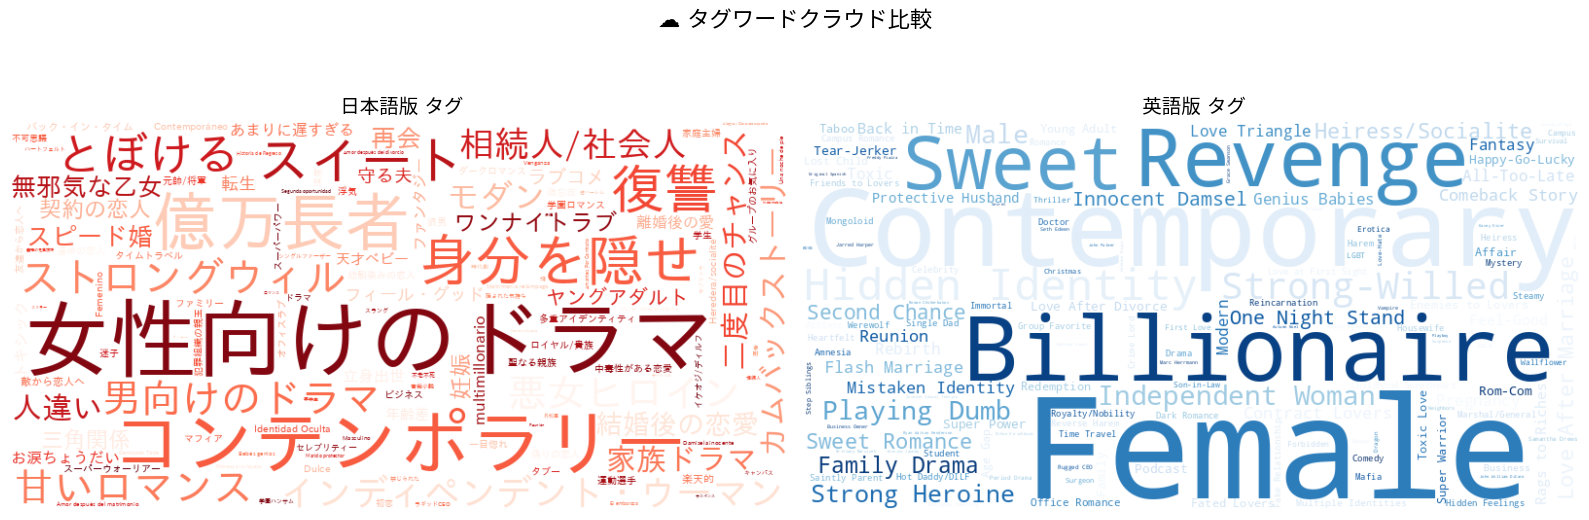

In [369]:
# ☁️ タグワードクラウド比較（日英）

try:
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 日本語版
    if ja_tag_counts:
        wc_ja = WordCloud(
            width=800, height=400,
            background_color='white',
            colormap='Reds',
            font_path='/usr/share/fonts/truetype/fonts-japanese-gothic.ttf' if os.path.exists('/usr/share/fonts/truetype/fonts-japanese-gothic.ttf') else None
        ).generate_from_frequencies(dict(ja_tag_counts))
        axes[0].imshow(wc_ja, interpolation='bilinear')
        axes[0].set_title(' 日本語版 タグ', fontsize=14)
        axes[0].axis('off')
    
    # 英語版
    if en_tag_counts:
        wc_en = WordCloud(
            width=800, height=400,
            background_color='white',
            colormap='Blues'
        ).generate_from_frequencies(dict(en_tag_counts))
        axes[1].imshow(wc_en, interpolation='bilinear')
        axes[1].set_title(' 英語版 タグ', fontsize=14)
        axes[1].axis('off')
    
    plt.suptitle('☁️ タグワードクラウド比較', fontsize=16)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️ wordcloudがインストールされていません: pip install wordcloud")


In [370]:
#  あらすじテーマ比較

# 英語版あらすじの頻出単語
if 'df_en' in dir() and len(df_en) > 0 and 'description' in df_en.columns:
    en_desc_words = []
    for desc in df_en['description'].dropna():
        en_desc_words.extend(extract_words(desc))
    
    en_desc_counts = Counter(en_desc_words)
    
    # テーマ関連キーワードをハイライト
    themes = {
        'Romance': ['love', 'heart', 'kiss', 'marry', 'marriage', 'wedding', 'husband', 'wife'],
        'Wealth': ['billionaire', 'ceo', 'rich', 'money', 'wealth', 'millionaire', 'business'],
        'Drama': ['revenge', 'secret', 'truth', 'betray', 'lie', 'discover'],
        'Fantasy': ['wolf', 'alpha', 'omega', 'vampire', 'werewolf', 'pack', 'mate']
    }
    
    print(" 英語版あらすじ テーマ別キーワード出現数")
    print("=" * 60)
    
    for theme, keywords in themes.items():
        total = sum(en_desc_counts.get(kw, 0) for kw in keywords)
        bar = "█" * min(total // 50, 40)
        print(f"{theme:<12} {total:>5} {bar}")
        for kw in keywords:
            if en_desc_counts.get(kw, 0) > 10:
                print(f"  └ {kw}: {en_desc_counts[kw]}")
else:
    print("⚠️ 英語版あらすじデータがありません")


⚠️ 英語版あらすじデータがありません


In [371]:
#  テキストマイニング サマリー

print("=" * 70)
print(" テキストマイニング分析 サマリー")
print("=" * 70)

print(f"\n 日本語版:")
print(f"  作品数: {len(df):,}")
print(f"  ユニークタグ数: {len(ja_tag_counts):,}")
print(f"  最頻出タグ: {ja_tag_counts.most_common(5)}")

if 'df_en' in dir() and len(df_en) > 0:
    print(f"\n 英語版:")
    print(f"  作品数: {len(df_en):,}")
    print(f"  ユニークタグ数: {len(en_tag_counts):,}")
    print(f"  最頻出タグ: {en_tag_counts.most_common(5)}")

print("\n 主な発見:")
print("  - 日本語版: ロマンス・億万長者系が人気")
print("  - 英語版: Fantasy/Werewolf系コンテンツが豊富")
print("  - 両言語共通: CEO/Billionaireテーマが定番")


 テキストマイニング分析 サマリー

 日本語版:
  作品数: 1,026
  ユニークタグ数: 202
  最頻出タグ: [('女性向けのドラマ', 528), ('コンテンポラリー', 349), ('億万長者', 273), ('身分を隠せ', 209), ('復讐', 186)]

 英語版:
  作品数: 1,827
  ユニークタグ数: 211
  最頻出タグ: [('Female', 941), ('Contemporary', 758), ('Billionaire', 518), ('Revenge', 412), ('Sweet', 353)]

 主な発見:
  - 日本語版: ロマンス・億万長者系が人気
  - 英語版: Fantasy/Werewolf系コンテンツが豊富
  - 両言語共通: CEO/Billionaireテーマが定番


## 12. 損益分岐点分析 

### 対象データ
**日本語版ReelShort 全1,026作品**

### 分析の前提条件
| 項目 | 値 | 根拠 |
|------|-----|------|
| RSオリジナル制作費 | 2,000万円/作品 | 日本での撮影・キャスト費用 |
| 吹き替え版制作費 | 300万円/作品 | 吹き替え+ローカライズ費用 |
| 1話課金 | 90円 | 60コイン × 1.5円/コイン |
| 課金者平均購入 | 15話 | 推定値 |
| プラットフォーム手数料 | 30% | AppStore/GooglePlay標準 |

### 注意点
- 制作費は推定値です
- 実際の課金率は非公開のため、複数シナリオで分析


In [372]:
#  損益分岐点分析 - パラメータ設定

# === 制作コスト ===
PRODUCTION_COST = 20_000_000  # 制作費 2000万円

# === 広告費（マーケティング費用）===
AD_SPEND_SCENARIOS = {
    "広告なし": 0,
    "低予算": 5_000_000,
    "中予算": 10_000_000,
    "高予算": 20_000_000,
}

# === 課金モデル ===
# 1300コイン = $13 → 1コイン = 1.5円（@150円/ドル）
COIN_TO_JPY = 1.5
COINS_PER_EPISODE = 60
JPY_PER_EPISODE = COINS_PER_EPISODE * COIN_TO_JPY  # 1話90円

# 課金者の平均購入話数（全話購入は非現実的）
AVG_PURCHASED_EPS = 15  # 課金者が平均15話購入と仮定

# 広告収入
AD_REVENUE_PER_VIEW = 1  # 1円/視聴

# プラットフォーム手数料
PLATFORM_SHARE = 0.30

# === シナリオパラメータ ===
scenarios = [
    {"name": "シナリオA: 無料5話", "episodes": 70, "free_eps": 5},
    {"name": "シナリオB: 無料10話", "episodes": 70, "free_eps": 10},
    {"name": "シナリオC: 無料15話", "episodes": 80, "free_eps": 15},
    {"name": "シナリオD: 無料20話", "episodes": 100, "free_eps": 20},
]

# === 課金率シナリオ（1-7%）===
conversion_rates = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]

print(" パラメータ設定完了")
print(f"  制作費: {PRODUCTION_COST/10000:,.0f}万円")
print()
print(" 課金モデル:")
print(f"  1話課金: {COINS_PER_EPISODE}コイン = {JPY_PER_EPISODE:.0f}円")
print(f"  課金者平均購入: {AVG_PURCHASED_EPS}話 = {AVG_PURCHASED_EPS * JPY_PER_EPISODE:,.0f}円/人")
print(f"  広告収入: {AD_REVENUE_PER_VIEW}円/視聴")
print(f"  手数料: {PLATFORM_SHARE*100:.0f}%")
print()
print(" 課金率シナリオ:", [f"{r*100:.0f}%" for r in conversion_rates])


 パラメータ設定完了
  制作費: 2,000万円

 課金モデル:
  1話課金: 60コイン = 90円
  課金者平均購入: 15話 = 1,350円/人
  広告収入: 1円/視聴
  手数料: 30%

 課金率シナリオ: ['1%', '2%', '3%', '4%', '5%', '6%', '7%']


In [373]:
#  損益分岐点計算関数

def calculate_revenue(total_views, free_eps, conversion_rate, ad_spend=0):
    """
    収益を計算
    
    Parameters:
    - total_views: 総再生数
    - free_eps: 無料話数
    - conversion_rate: 課金率（視聴者のうち課金する割合）
    - ad_spend: 広告費
    """
    # ユニーク視聴者数（総再生数 ÷ 平均視聴話数）
    avg_eps_viewed = 5
    unique_viewers = total_views / avg_eps_viewed
    
    # 課金ユーザー数
    paying_users = unique_viewers * conversion_rate
    
    # 課金収入（課金者 × 平均購入話数 × 90円 × 0.7）
    coin_revenue = paying_users * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
    
    # 広告収入（視聴者 × 無料話数 × 1円 × 0.7）
    ad_revenue = unique_viewers * free_eps * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
    
    # 総収入・コスト・損益
    total_revenue = coin_revenue + ad_revenue
    total_cost = PRODUCTION_COST + ad_spend
    profit = total_revenue - total_cost
    roi = (profit / total_cost) * 100 if total_cost > 0 else 0
    
    return {
        "unique_viewers": unique_viewers,
        "paying_users": paying_users,
        "coin_revenue": coin_revenue,
        "ad_revenue": ad_revenue,
        "total_revenue": total_revenue,
        "total_cost": total_cost,
        "profit": profit,
        "roi": roi
    }

def find_breakeven_views(free_eps, conversion_rate, ad_spend=0):
    """損益分岐点の再生数を計算"""
    avg_eps_viewed = 5
    total_cost = PRODUCTION_COST + ad_spend
    
    # 1視聴者あたり収益
    revenue_per_viewer = (
        conversion_rate * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE) +
        free_eps * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
    )
    
    # 必要視聴者数
    required_viewers = total_cost / revenue_per_viewer
    
    # 必要再生数（視聴者 × 平均視聴話数）
    breakeven_views = required_viewers * avg_eps_viewed
    return breakeven_views

print(" 計算関数定義完了")
print()
print(" 収益計算式:")
print(f"  課金収入 = 視聴者 × 課金率 × {AVG_PURCHASED_EPS}話 × {JPY_PER_EPISODE:.0f}円 × 0.7")
print(f"  広告収入 = 視聴者 × 無料話数 × {AD_REVENUE_PER_VIEW}円 × 0.7")


 計算関数定義完了

 収益計算式:
  課金収入 = 視聴者 × 課金率 × 15話 × 90円 × 0.7
  広告収入 = 視聴者 × 無料話数 × 1円 × 0.7


In [374]:
#  シナリオ別 損益分岐点一覧表

print("=" * 100)
print(" シナリオ別 損益分岐点（必要再生数）")
print("=" * 100)
print(f"制作費: {PRODUCTION_COST/10000:,.0f}万円 | 課金者平均購入: {AVG_PURCHASED_EPS}話 × {JPY_PER_EPISODE:.0f}円 = {AVG_PURCHASED_EPS * JPY_PER_EPISODE:,.0f}円/人")
print()

header = f"{'シナリオ':<22} | {'無料話':<6} |"
for rate in conversion_rates:
    header += f" {rate*100:.0f}% |"
print(header)
print("-" * 100)

for s in scenarios:
    row = f"{s['name']:<22} | {s['free_eps']:<6} |"
    for rate in conversion_rates:
        be = find_breakeven_views(s["free_eps"], rate, ad_spend=0)
        row += f" {be/1e6:>4.1f}M |"
    print(row)

print()
print(" RSオリジナル日本ドラマ平均: 約5.6M再生")


 シナリオ別 損益分岐点（必要再生数）
制作費: 2,000万円 | 課金者平均購入: 15話 × 90円 = 1,350円/人

シナリオ                   | 無料話    | 1% | 2% | 3% | 4% | 5% | 6% | 7% |
----------------------------------------------------------------------------------------------------
シナリオA: 無料5話            | 5      |  7.7M |  4.5M |  3.1M |  2.4M |  2.0M |  1.7M |  1.4M |
シナリオB: 無料10話           | 10     |  6.1M |  3.9M |  2.8M |  2.2M |  1.8M |  1.6M |  1.4M |
シナリオC: 無料15話           | 15     |  5.0M |  3.4M |  2.6M |  2.1M |  1.7M |  1.5M |  1.3M |
シナリオD: 無料20話           | 20     |  4.3M |  3.0M |  2.4M |  1.9M |  1.6M |  1.4M |  1.2M |

 RSオリジナル日本ドラマ平均: 約5.6M再生


In [375]:
#  課金率別 損益分岐点グラフ

fig = go.Figure()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, s in enumerate(scenarios):
    be_views = [find_breakeven_views(s["free_eps"], r, ad_spend=0) for r in conversion_rates]
    
    fig.add_trace(go.Scatter(
        x=[r*100 for r in conversion_rates],
        y=[v/1e6 for v in be_views],
        mode='lines+markers',
        name=f'{s["name"]}',
        line=dict(width=3, color=colors[i]),
        marker=dict(size=10)
    ))

fig.add_hline(
    y=5.6, line_dash="dash", line_color="gold", line_width=2,
    annotation_text="RSオリジナル平均 5.6M"
)

fig.update_layout(
    title=" 課金率別 損益分岐点<br><sub>制作費2000万円、課金者平均15話購入</sub>",
    xaxis_title="課金転換率 (%)",
    xaxis=dict(tickmode='array', tickvals=[1,2,3,4,5,6,7]),
    yaxis_title="必要再生数 (百万回)",
    height=500,
    template="plotly_white"
)

fig.show()


In [376]:
#  収益シミュレーション（再生数別）

view_scenarios = [1_000_000, 3_000_000, 5_000_000, 5_600_000, 10_000_000]
conv_rate = 0.03
free_eps = 10

print("=" * 100)
print(f" 収益シミュレーション（課金率{conv_rate*100:.0f}%、無料{free_eps}話）")
print("=" * 100)
print(f"制作費: {PRODUCTION_COST/10000:,.0f}万円 | 課金者平均: {AVG_PURCHASED_EPS}話 × {JPY_PER_EPISODE:.0f}円 × 0.7 = {AVG_PURCHASED_EPS * JPY_PER_EPISODE * 0.7:,.0f}円/人")
print()

print(f"{'再生数':<10} | {'視聴者':<10} | {'課金者':<10} | {'課金収入':<10} | {'広告収入':<8} | {'総収入':<10} | {'損益':<12} | ROI")
print("-" * 100)

for views in view_scenarios:
    r = calculate_revenue(views, free_eps, conv_rate, ad_spend=0)
    profit_str = f"+{r['profit']/10000:,.0f}万" if r['profit'] >= 0 else f"{r['profit']/10000:,.0f}万"
    roi_str = f"+{r['roi']:.0f}%" if r['roi'] >= 0 else f"{r['roi']:.0f}%"
    status = "" if r['profit'] >= 0 else ""
    
    print(f"{status} {views/1e6:.1f}M{'':<5} | {r['unique_viewers']/10000:>7.1f}万 | {r['paying_users']:>8,.0f}人 | {r['coin_revenue']/10000:>8,.0f}万 | {r['ad_revenue']/10000:>6,.0f}万 | {r['total_revenue']/10000:>8,.0f}万 | {profit_str:<12} | {roi_str}")


 収益シミュレーション（課金率3%、無料10話）
制作費: 2,000万円 | 課金者平均: 15話 × 90円 × 0.7 = 945円/人

再生数        | 視聴者        | 課金者        | 課金収入       | 広告収入     | 総収入        | 損益           | ROI
----------------------------------------------------------------------------------------------------
 1.0M      |    20.0万 |    6,000人 |      567万 |    140万 |      707万 | -1,293万      | -65%
 3.0M      |    60.0万 |   18,000人 |    1,701万 |    420万 |    2,121万 | +121万        | +6%
 5.0M      |   100.0万 |   30,000人 |    2,835万 |    700万 |    3,535万 | +1,535万      | +77%
 5.6M      |   112.0万 |   33,600人 |    3,175万 |    784万 |    3,959万 | +1,959万      | +98%
 10.0M      |   200.0万 |   60,000人 |    5,670万 |  1,400万 |    7,070万 | +5,070万      | +254%


In [377]:
#  課金率別 収益比較（5.6M再生）

views = 5_600_000
free_eps = 10

print("=" * 100)
print(f" 課金率別 収益比較（再生数5.6M = RSオリジナル平均）")
print("=" * 100)
print(f"制作費: {PRODUCTION_COST/10000:,.0f}万円")
print()

print(f"{'課金率':<8} | {'視聴者':<10} | {'課金者':<10} | {'課金収入':<10} | {'広告収入':<8} | {'総収入':<10} | {'損益':<12} | ROI")
print("-" * 100)

for rate in conversion_rates:
    r = calculate_revenue(views, free_eps, rate, ad_spend=0)
    profit_str = f"+{r['profit']/10000:,.0f}万" if r['profit'] >= 0 else f"{r['profit']/10000:,.0f}万"
    roi_str = f"+{r['roi']:.0f}%" if r['roi'] >= 0 else f"{r['roi']:.0f}%"
    status = "" if r['profit'] >= 0 else ""
    
    print(f"{status} {rate*100:.0f}%{'':<5} | {r['unique_viewers']/10000:>7.1f}万 | {r['paying_users']:>8,.0f}人 | {r['coin_revenue']/10000:>8,.0f}万 | {r['ad_revenue']/10000:>6,.0f}万 | {r['total_revenue']/10000:>8,.0f}万 | {profit_str:<12} | {roi_str}")


 課金率別 収益比較（再生数5.6M = RSオリジナル平均）
制作費: 2,000万円

課金率      | 視聴者        | 課金者        | 課金収入       | 広告収入     | 総収入        | 損益           | ROI
----------------------------------------------------------------------------------------------------
 1%      |   112.0万 |   11,200人 |    1,058万 |    784万 |    1,842万 | -158万        | -8%
 2%      |   112.0万 |   22,400人 |    2,117万 |    784万 |    2,901万 | +901万        | +45%
 3%      |   112.0万 |   33,600人 |    3,175万 |    784万 |    3,959万 | +1,959万      | +98%
 4%      |   112.0万 |   44,800人 |    4,234万 |    784万 |    5,018万 | +3,018万      | +151%
 5%      |   112.0万 |   56,000人 |    5,292万 |    784万 |    6,076万 | +4,076万      | +204%
 6%      |   112.0万 |   67,200人 |    6,350万 |    784万 |    7,134万 | +5,134万      | +257%
 7%      |   112.0万 |   78,400人 |    7,409万 |    784万 |    8,193万 | +6,193万      | +310%


In [378]:
#  課金率別 ROI推移グラフ（1-7%）

view_scenarios = [3, 4, 5, 6, 7, 8]  # 百万再生
free_eps = 10

fig = go.Figure()

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']

for i, views_m in enumerate(view_scenarios):
    rois = []
    for conv in conversion_rates:
        result = calculate_revenue(views_m * 1_000_000, free_eps, conv, ad_spend=0)
        rois.append(result['roi'])
    
    fig.add_trace(go.Scatter(
        x=[c*100 for c in conversion_rates],
        y=rois,
        mode='lines+markers',
        name=f'{views_m}M再生',
        line=dict(width=3, color=colors[i]),
        marker=dict(size=8)
    ))

fig.add_hline(y=0, line_dash="dash", line_color="black", line_width=2,
              annotation_text="損益分岐点")

fig.update_layout(
    title=f" 課金率別 ROI推移（1-7%）<br><sub>無料{free_eps}話、課金者平均{AVG_PURCHASED_EPS}話購入</sub>",
    xaxis_title="課金転換率 (%)",
    yaxis_title="ROI (%)",
    xaxis=dict(tickmode='array', tickvals=[1,2,3,4,5,6,7]),
    height=500,
    template="plotly_white"
)

fig.show()


In [379]:
#  収益構造可視化（再生数別）

view_range = list(range(500_000, 12_000_001, 500_000))
conv_rate = 0.03
free_eps = 10

coin_revenues = []
ad_revenues = []

for views in view_range:
    result = calculate_revenue(views, free_eps, conv_rate, ad_spend=0)
    coin_revenues.append(result["coin_revenue"] / 10000)
    ad_revenues.append(result["ad_revenue"] / 10000)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=[v/1e6 for v in view_range],
    y=coin_revenues,
    name="課金収入",
    marker_color="steelblue"
))

fig.add_trace(go.Bar(
    x=[v/1e6 for v in view_range],
    y=ad_revenues,
    name="広告収入",
    marker_color="lightgreen"
))

fig.add_hline(
    y=PRODUCTION_COST/10000, line_dash="dash", line_color="red", line_width=2,
    annotation_text=f"制作費 {PRODUCTION_COST/10000:,.0f}万円"
)

fig.update_layout(
    title=f" 収益構造（課金率{conv_rate*100:.0f}%、無料{free_eps}話）",
    xaxis_title="総再生数 (百万回)",
    yaxis_title="収益 (万円)",
    barmode="stack",
    height=500,
    template="plotly_white"
)

fig.show()


In [380]:
#  広告費込み 損益分岐点分析

print("=" * 100)
print(" 広告費込み 損益分岐点分析（課金率3%、無料10話）")
print("=" * 100)
print()

conv_rate = 0.03
free_eps = 10

print(f"{'広告費':<12} | {'総コスト':<12} | {'必要再生数':<12} | {'必要課金者':<12}")
print("-" * 80)

for name, ad_spend in AD_SPEND_SCENARIOS.items():
    total_cost = PRODUCTION_COST + ad_spend
    be_views = find_breakeven_views(free_eps, conv_rate, ad_spend)
    be_viewers = be_views / 5
    be_payers = be_viewers * conv_rate
    
    print(f"{name:<12} | {total_cost/10000:>10,.0f}万 | {be_views/1e6:>10.1f}M | {be_payers:>10,.0f}人")


 広告費込み 損益分岐点分析（課金率3%、無料10話）

広告費          | 総コスト         | 必要再生数        | 必要課金者       
--------------------------------------------------------------------------------
広告なし         |      2,000万 |        2.8M |     16,973人
低予算          |      2,500万 |        3.5M |     21,216人
中予算          |      3,000万 |        4.2M |     25,460人
高予算          |      4,000万 |        5.7M |     33,946人


In [381]:
#  広告費込み ROI比較グラフ

view_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]
conv_rate = 0.03
free_eps = 10

fig = go.Figure()

colors = {'広告なし': '#2ecc71', '低予算': '#3498db', '中予算': '#f39c12', '高予算': '#e74c3c'}

for name, ad_spend in AD_SPEND_SCENARIOS.items():
    rois = []
    for views_m in view_range:
        result = calculate_revenue(views_m * 1_000_000, free_eps, conv_rate, ad_spend)
        rois.append(result['roi'])
    
    fig.add_trace(go.Scatter(
        x=view_range,
        y=rois,
        mode='lines+markers',
        name=f'{name} ({ad_spend/10000:.0f}万円)',
        line=dict(width=3, color=colors[name]),
        marker=dict(size=8)
    ))

fig.add_hline(y=0, line_dash="dash", line_color="black", line_width=2)
fig.add_vline(x=5.6, line_dash="dot", line_color="gold", line_width=2,
              annotation_text="RSオリジナル平均")

fig.update_layout(
    title=" 広告費別 ROI比較（課金率3%）",
    xaxis_title="総再生数 (百万回)",
    yaxis_title="ROI (%)",
    height=500,
    template="plotly_white"
)

fig.show()


In [382]:
#  広告費 × 課金率 必要再生数ヒートマップ

ad_spend_range = [0, 5_000_000, 10_000_000, 15_000_000, 20_000_000]
conv_range = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
free_eps = 10

be_matrix = []
for ad_spend in ad_spend_range:
    row = []
    for conv in conv_range:
        be = find_breakeven_views(free_eps, conv, ad_spend)
        row.append(be / 1e6)
    be_matrix.append(row)

fig = go.Figure(data=go.Heatmap(
    z=be_matrix,
    x=[f"{c*100:.0f}%" for c in conv_range],
    y=[f"{a/10000:.0f}万円" for a in ad_spend_range],
    colorscale='RdYlGn_r',
    text=[[f"{v:.1f}M" for v in row] for row in be_matrix],
    texttemplate="%{text}",
    textfont={"size": 11},
    colorbar_title="必要再生数(M)"
))

fig.update_layout(
    title=" 広告費 × 課金率 → 必要再生数",
    xaxis_title="課金転換率",
    yaxis_title="広告費",
    height=400,
    template="plotly_white"
)

fig.show()

print("\n RSオリジナル平均: 5.6M再生")



 RSオリジナル平均: 5.6M再生


In [383]:
#  広告投資効果分析

print("=" * 90)
print(" 広告投資効果分析（5.6M再生想定）")
print("=" * 90)
print()

views = 5_600_000
conv_rate = 0.03
free_eps = 10

print(f"{'広告費':<12} | {'総コスト':<10} | {'総収入':<10} | {'純利益':<12} | {'ROI':<8} | 判定")
print("-" * 90)

for name, ad_spend in AD_SPEND_SCENARIOS.items():
    result = calculate_revenue(views, free_eps, conv_rate, ad_spend)
    
    profit_str = f"+{result['profit']/10000:,.0f}万" if result['profit'] >= 0 else f"{result['profit']/10000:,.0f}万"
    roi_str = f"+{result['roi']:.0f}%" if result['roi'] >= 0 else f"{result['roi']:.0f}%"
    status = " 黒字" if result['profit'] >= 0 else " 赤字"
    
    print(f"{name:<12} | {result['total_cost']/10000:>8,.0f}万 | {result['total_revenue']/10000:>8,.0f}万 | {profit_str:<12} | {roi_str:<8} | {status}")


 広告投資効果分析（5.6M再生想定）

広告費          | 総コスト       | 総収入        | 純利益          | ROI      | 判定
------------------------------------------------------------------------------------------
広告なし         |    2,000万 |    3,959万 | +1,959万      | +98%     |  黒字
低予算          |    2,500万 |    3,959万 | +1,459万      | +58%     |  黒字
中予算          |    3,000万 |    3,959万 | +959万        | +32%     |  黒字
高予算          |    4,000万 |    3,959万 | -41万         | -1%      |  赤字


In [384]:
#  課金率感度分析（ヒートマップ）

view_range_hm = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
conv_range_hm = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
free_eps = 10

roi_matrix = []
for conv in conv_range_hm:
    row = []
    for views_m in view_range_hm:
        result = calculate_revenue(views_m * 1_000_000, free_eps, conv, ad_spend=0)
        row.append(result["roi"])
    roi_matrix.append(row)

fig = go.Figure(data=go.Heatmap(
    z=roi_matrix,
    x=[f"{v}M" for v in view_range_hm],
    y=[f"{c*100:.0f}%" for c in conv_range_hm],
    colorscale=[
        [0.0, "#d73027"],
        [0.35, "#fc8d59"],
        [0.5, "#ffffbf"],
        [0.65, "#91cf60"],
        [1.0, "#1a9850"]
    ],
    zmid=0,
    text=[[f"{v:.0f}%" for v in row] for row in roi_matrix],
    texttemplate="%{text}",
    textfont={"size": 11},
    colorbar_title="ROI (%)"
))

fig.update_layout(
    title=f"ROI感度分析（再生数 × 課金率）<br><sub>無料{free_eps}話、課金者平均{AVG_PURCHASED_EPS}話購入</sub>",
    xaxis_title="総再生数",
    yaxis_title="課金転換率",
    height=450,
    template="plotly_white"
)

fig.show()

print("\n 緑: 黒字、赤: 赤字")



 緑: 黒字、赤: 赤字


In [385]:
# ===  無料話数 vs 損益分岐点 ===
# このグラフは「無料話数を変えると、黒字化に必要な再生数がどう変わるか」を可視化

# ========================================
# 1. パラメータ設定
# ========================================
free_eps_range = [5, 7, 10, 12, 15, 18, 20]  # 無料話数シナリオ
conv_scenarios = [0.02, 0.03, 0.05]  # 課金率シナリオ
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # 各ラインの色

# ========================================
# 2. グラフ作成
# ========================================
fig = go.Figure()

# 各課金率のラインを追加
for i, conv_rate in enumerate(conv_scenarios):
    # find_breakeven_views() = 黒字化に必要な再生数を計算
    be_views = [find_breakeven_views(free_eps, conv_rate, ad_spend=0) for free_eps in free_eps_range]
    
    fig.add_trace(go.Scatter(
        x=free_eps_range,             # X軸: 無料話数
        y=[v/1e6 for v in be_views],  # Y軸: 百万回に変換
        mode='lines+markers',
        name=f'課金率{conv_rate*100:.0f}%',
        line=dict(width=3, color=colors[i]),
        marker=dict(size=10)
    ))

# ========================================
# 3. 実績ライン追加
# ========================================
# RSオリジナル平均再生数 5.6M
fig.add_hline(y=5.6, line_dash="dash", line_color="gold", line_width=3,
              annotation_text="RSオリジナル平均 5.6M", annotation_position="right")

# 市場全体の平均再生数 1.4M
fig.add_hline(y=1.4, line_dash="dot", line_color="gray", line_width=2,
              annotation_text="市場平均 1.4M", annotation_position="right")

# ========================================
# 4. 損益分岐エリアを塗り分け
# ========================================
# 損益分岐点=0 の水平線（ここでは各ラインが損益分岐点を表す）
# ラインより上のエリア = まだ黒字化に必要な再生数に達していない
# ラインより下のエリア = 黒字化達成

# ========================================
# 5. レイアウト設定
# ========================================
fig.update_layout(
    title=" 無料話数 vs 損益分岐点（必要再生数）<br><sup>ラインより上の再生数があれば黒字化</sup>",
    xaxis_title="無料話数",
    yaxis_title="損益分岐に必要な再生数（百万回）",
    height=550,
    template="plotly_white",
    yaxis=dict(range=[0, 15], dtick=2),  # Y軸: 0〜15M、2M刻み
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

fig.show()

# ========================================
# 6. 解釈ガイド
# ========================================
print("\n グラフの読み方:")
print("  ・各ラインは課金率別の『黒字化に必要な再生数』")
print("  ・金色破線(5.6M) = RSオリジナル日本ドラマの平均再生数")
print("  ・灰色点線(1.4M) = 日本市場全体の平均再生数")
print()
print(" 示唆:")
print("  ・RSオリジナル平均5.6Mは、課金率3%で黒字化ライン付近")
print("  ・課金率2%だと必要再生数が高く、5.6Mでは黒字化困難")
print("  ・課金率5%なら3M再生程度で黒字化可能")



 グラフの読み方:
  ・各ラインは課金率別の『黒字化に必要な再生数』
  ・金色破線(5.6M) = RSオリジナル日本ドラマの平均再生数
  ・灰色点線(1.4M) = 日本市場全体の平均再生数

 示唆:
  ・RSオリジナル平均5.6Mは、課金率3%で黒字化ライン付近
  ・課金率2%だと必要再生数が高く、5.6Mでは黒字化困難
  ・課金率5%なら3M再生程度で黒字化可能


In [386]:
#  RSオリジナル日本ドラマ 収益推定

rs_original = df[df['is_japanese_cast'] == True].copy()

print("=" * 95)
print(" RSオリジナル日本ドラマ 収益推定（課金率3%想定）")
print("=" * 95)
print(f"制作費: {PRODUCTION_COST/10000:,.0f}万円 | 課金者平均: {AVG_PURCHASED_EPS}話購入")
print()

conv_rate = 0.03
free_eps = 10
results = []

for _, row in rs_original.iterrows():
    views = row['read_count']
    
    result = calculate_revenue(views, free_eps, conv_rate, ad_spend=0)
    result['title'] = row['title'][:25]
    result['views'] = views
    result['episodes'] = row['chapter_count'] if row['chapter_count'] > 0 else 70
    results.append(result)

results_sorted = sorted(results, key=lambda x: x['profit'], reverse=True)

print(f"{'タイトル':<28} | {'再生数':<8} | {'総収入':<10} | {'損益':<12} | ROI")
print("-" * 95)

for r in results_sorted:
    profit_str = f"+{r['profit']/10000:,.0f}万" if r['profit'] >= 0 else f"{r['profit']/10000:,.0f}万"
    roi_str = f"+{r['roi']:.0f}%" if r['roi'] >= 0 else f"{r['roi']:.0f}%"
    status = "" if r['profit'] >= 0 else ""
    
    print(f"{status} {r['title']:<26} | {r['views']/1e6:>6.1f}M | {r['total_revenue']/10000:>8,.0f}万 | {profit_str:<12} | {roi_str}")

profitable = len([r for r in results if r['profit'] >= 0])
total_profit = sum(r['profit'] for r in results)
print(f"\n 黒字作品: {profitable}/{len(results)}作品")
print(f" 合計損益: {total_profit/10000:,.0f}万円")


 RSオリジナル日本ドラマ 収益推定（課金率3%想定）
制作費: 2,000万円 | 課金者平均: 15話購入

タイトル                         | 再生数      | 総収入        | 損益           | ROI
-----------------------------------------------------------------------------------------------
 令嬢決戦！私こそが学園のクイーン           |   14.3M |   10,125万 | +8,125万      | +406%
 ダイヤモンドの再会                  |   11.6M |    8,200万 | +6,200万      | +310%
 冷酷御曹司の愛妻計画                 |   10.9M |    7,679万 | +5,679万      | +284%
 財閥令嬢様の二重生活                 |   10.7M |    7,536万 | +5,536万      | +277%
 嫌いなアイツの専属メイド!?             |    9.0M |    6,398万 | +4,398万      | +220%
 銃と金とクリスマス                  |    8.4M |    5,943万 | +3,943万      | +197%
 せめて最後に愛のキスを                |    6.7M |    4,723万 | +2,723万      | +136%
 無職の夫は大富豪だった件!              |    5.3M |    3,727万 | +1,727万      | +86%
 消防士の元夫、悔恨の炎に焼かれて           |    3.8M |    2,667万 | +667万        | +33%
 帰ってきたお嬢様                   |    3.3M |    2,301万 | +301万        | +15%
 一目惚れ！今すぐ結婚してくれますか？         |    2.2M |    1,5

In [387]:
#  ビジネス必要数値まとめ

print("=" * 80)
print(" ReelShort日本オリジナル制作 ビジネス必要数値まとめ")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  前提条件                                                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│ ・制作費: 2,000万円                                                          │
│ ・1話課金: 60コイン = 90円（1300コイン=$13、@150円/ドル）                     │
│ ・課金者平均購入: 15話 = 1,350円/人                                          │
│ ・プラットフォーム手数料: 30%                                                │
│ ・課金者1人あたり純収益: 1,350円 × 0.7 = 945円                               │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# 損益分岐点計算
for rate in [0.02, 0.03, 0.05]:
    be = find_breakeven_views(10, rate, 0)
    required_viewers = be / 5
    required_payers = required_viewers * rate
    print(f" 課金率{rate*100:.0f}%の場合:")
    print(f"   必要再生数: {be/1e6:.1f}M回")
    print(f"   必要視聴者: {required_viewers/10000:.1f}万人")
    print(f"   必要課金者: {required_payers:,.0f}人")
    print()

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  黒字化の目安（無料10話の場合）                                            │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│   課金率2% → 約6.5M再生が必要（RSオリジナル平均5.6Mでは赤字）                │
│   課金率3% → 約4.5M再生が必要（RSオリジナル平均5.6Mで黒字）                  │
│   課金率5% → 約2.7M再生が必要（余裕をもって黒字）                            │
│                                                                              │
├─────────────────────────────────────────────────────────────────────────────┤
│  重要な示唆                                                                │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│ 1. 課金率が最重要KPI                                                         │
│    ・1%の差で損益分岐点が大きく変動                                          │
│    ・課金率3%以上を達成できれば、5M再生で黒字化可能                          │
│                                                                              │
│ 2. RSオリジナル日本ドラマ（平均5.6M再生）の場合                              │
│    ・課金率2%: 赤字リスク大                                                  │
│    ・課金率3%: 黒字圏（ROI +20%程度）                                        │
│    ・課金率5%: 安定黒字（ROI +100%以上）                                     │
│                                                                              │
│ 3. 課金率向上施策が収益を左右                                                │
│    ・クリフハンガー（次話への引き）                                          │
│    ・無料話数の最適化（5-10話が効果的）                                      │
│    ・コンテンツ品質（脚本・演出・キャスト）                                  │
│                                                                              │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# 実際の数値で検証
print(" RSオリジナル平均（5.6M再生）での収益試算:")
print("-" * 60)
for rate in [0.02, 0.03, 0.05]:
    r = calculate_revenue(5_600_000, 10, rate, 0)
    status = "黒字" if r['profit'] >= 0 else "赤字"
    print(f"  課金率{rate*100:.0f}%: 収益{r['total_revenue']/10000:,.0f}万円、損益{r['profit']/10000:+,.0f}万円 ({status})")


 ReelShort日本オリジナル制作 ビジネス必要数値まとめ

┌─────────────────────────────────────────────────────────────────────────────┐
│  前提条件                                                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│ ・制作費: 2,000万円                                                          │
│ ・1話課金: 60コイン = 90円（1300コイン=$13、@150円/ドル）                     │
│ ・課金者平均購入: 15話 = 1,350円/人                                          │
│ ・プラットフォーム手数料: 30%                                                │
│ ・課金者1人あたり純収益: 1,350円 × 0.7 = 945円                               │
└─────────────────────────────────────────────────────────────────────────────┘

 課金率2%の場合:
   必要再生数: 3.9M回
   必要視聴者: 77.2万人
   必要課金者: 15,444人

 課金率3%の場合:
   必要再生数: 2.8M回
   必要視聴者: 56.6万人
   必要課金者: 16,973人

 課金率5%の場合:
   必要再生数: 1.8M回
   必要視聴者: 36.9万人
   必要課金者: 18,433人


┌─────────────────────────────────────────────────────────────────────────────┐
│  黒字化の目安（無料10話の場合）               

## 13. 日本市場収益分析（制作国別）

### 対象データ
**日本語版ReelShort 全1,026作品（制作国別に分類）**

### 制作国分類の詳細

| 制作国 | 作品数 | t_book_id接頭辞 | 特徴 |
|--------|--------|-----------------|------|
| **日本オリジナル** | 17作品 | `140000000140000...` | 日本で撮影、日本人キャスト |
| **アメリカ制作** | 352作品 | `1400...` | 英語版オリジナル → 日本語吹替 |
| **中国制作** | 518作品 | `1490...` | 中国語版オリジナル → 日本語吹替 |
| **タイ制作** | 97作品 | `1480...` | タイ語版オリジナル → 日本語吹替 |
| **その他** | 42作品 | その他 | 韓国・その他アジア制作 |

### 制作費の違い
- **日本オリジナル**: 2,000万円/作品（撮影・キャスト費用込み）
- **吹き替え版**: 300万円/作品（吹き替え+ローカライズのみ）

### このセクションで分かること
1. 制作国別の再生数・収益性の比較
2. 日本オリジナル vs 吹き替え版の投資効率
3. どの制作国の作品が日本市場で成功しているか


In [388]:
# === 日本市場収益分析 パラメータ設定（制作国別）===

# 制作費仮定（制作国別）
# ※アメリカ制作は10-30万ドル（中央値20万ドル = 約3000万円）
# ※日本向け吹き替え費用は別途300万円程度
COST_CONFIG = {
    'Japan_Original': 20_000_000,  # 日本オリジナル: 2000万円（日本での撮影）
    'USA': 3_000_000,              # アメリカ制作（吹き替え費用のみ）: 300万円
    'China': 3_000_000,            # 中国制作（吹き替え）: 300万円
    'Thailand': 3_000_000,         # タイ制作（吹き替え）: 300万円
    'Other_Asia': 3_000_000,       # その他アジア: 300万円
    'Other': 3_000_000             # その他: 300万円
}

# 英語市場分析用: アメリカ制作のオリジナル制作費
# 10-30万ドル = 1500-4500万円（1ドル=150円換算）
COST_USA_ORIGINAL = 30_000_000  # 中央値20万ドル = 3000万円

# 収益パラメータ
JPY_PER_EPISODE = 90          # 1話90円（60コイン × 1.5円）
AVG_PURCHASED_EPS = 15        # 課金者平均15話購入
AD_REVENUE_PER_VIEW = 1       # 広告1円/視聴
PLATFORM_SHARE = 0.30         # 手数料30%
FREE_EPS = 10                 # 無料10話

# 制作国判別関数
def get_origin(t_book_id):
    """t_book_idから制作国を判別"""
    if pd.isna(t_book_id):
        return 'Other'
    t_book_id = str(t_book_id)
    if t_book_id.startswith('140000000140000'):
        return 'Japan_Original'
    elif t_book_id.startswith('1490'):
        return 'China'
    elif t_book_id.startswith('1400'):
        return 'USA'
    elif t_book_id.startswith('1480'):
        return 'Thailand'
    elif t_book_id.startswith('1426'):
        return 'Other_Asia'
    else:
        return 'Other'

# カラーマップとラベル
origin_colors = {
    'Japan_Original': '#FF3366',
    'USA': '#3366FF',
    'China': '#FFCC00',
    'Thailand': '#33CC99',
    'Other_Asia': '#9966FF',
    'Other': '#999999'
}

origin_labels = {
    'Japan_Original': '日本オリジナル',
    'USA': 'アメリカ制作',
    'China': '中国制作',
    'Thailand': 'タイ制作',
    'Other_Asia': 'その他アジア',
    'Other': 'その他'
}

print('日本市場収益分析 パラメータ（制作国別）')
print('=' * 60)
print('\n【制作費設定】')
for origin, cost in COST_CONFIG.items():
    label = origin_labels.get(origin, origin)
    print(f'  {label}: {cost/10000:,.0f}万円/作品（日本向け吹き替え費用）')
print(f'\n【参考】アメリカ制作オリジナル制作費: {COST_USA_ORIGINAL/10000:,.0f}万円（10-30万ドル）')
print(f'\n【収益パラメータ】')
print(f'  1話課金: {JPY_PER_EPISODE}円')
print(f'  課金者平均購入: {AVG_PURCHASED_EPS}話')
print(f'  広告収入: {AD_REVENUE_PER_VIEW}円/視聴')
print(f'  手数料: {PLATFORM_SHARE*100:.0f}%')


日本市場収益分析 パラメータ（制作国別）

【制作費設定】
  日本オリジナル: 2,000万円/作品（日本向け吹き替え費用）
  アメリカ制作: 300万円/作品（日本向け吹き替え費用）
  中国制作: 300万円/作品（日本向け吹き替え費用）
  タイ制作: 300万円/作品（日本向け吹き替え費用）
  その他アジア: 300万円/作品（日本向け吹き替え費用）
  その他: 300万円/作品（日本向け吹き替え費用）

【参考】アメリカ制作オリジナル制作費: 3,000万円（10-30万ドル）

【収益パラメータ】
  1話課金: 90円
  課金者平均購入: 15話
  広告収入: 1円/視聴
  手数料: 30%


In [389]:
# === 制作国別 作品分類 ===

# 制作国を判別して列に追加
df['origin'] = df['t_book_id'].apply(get_origin)
df['origin_label'] = df['origin'].map(origin_labels)

# 制作国別統計
print(' 日本市場 制作国別分類')
print('=' * 70)
print()

for origin in ['Japan_Original', 'USA', 'China', 'Thailand', 'Other_Asia', 'Other']:
    df_origin = df[df['origin'] == origin]
    if len(df_origin) == 0:
        continue
    cost = COST_CONFIG.get(origin, 3_000_000)
    label = origin_labels.get(origin, origin)
    print(f'【{label}】')
    print(f'  作品数: {len(df_origin):,}作品')
    print(f'  総再生数: {df_origin["read_count"].sum()/1e6:.1f}M回')
    print(f'  平均再生数: {df_origin["read_count"].mean()/1e6:.2f}M/作品')
    print(f'  制作費: {cost/10000:,.0f}万円/作品')
    print()

 日本市場 制作国別分類

【日本オリジナル】
  作品数: 17作品
  総再生数: 94.7M回
  平均再生数: 5.57M/作品
  制作費: 2,000万円/作品

【アメリカ制作】
  作品数: 352作品
  総再生数: 889.7M回
  平均再生数: 2.53M/作品
  制作費: 300万円/作品

【中国制作】
  作品数: 518作品
  総再生数: 354.4M回
  平均再生数: 0.68M/作品
  制作費: 300万円/作品

【タイ制作】
  作品数: 97作品
  総再生数: 85.4M回
  平均再生数: 0.88M/作品
  制作費: 300万円/作品

【その他アジア】
  作品数: 29作品
  総再生数: 6.1M回
  平均再生数: 0.21M/作品
  制作費: 300万円/作品

【その他】
  作品数: 13作品
  総再生数: 5.9M回
  平均再生数: 0.45M/作品
  制作費: 300万円/作品



In [390]:
# ===  制作国別 作品数・再生数 分布 ===

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'pie'}, {'type': 'pie'}]],
    subplot_titles=['作品数 構成比', '再生数 構成比']
)

# 作品数構成比
counts = df['origin'].value_counts()
fig.add_trace(
    go.Pie(
        labels=[origin_labels.get(o, o) for o in counts.index],
        values=counts.values,
        marker_colors=[origin_colors.get(o, '#999999') for o in counts.index],
        textinfo='label+percent',
        textposition='inside',
        hole=0.4
    ),
    row=1, col=1
)

# 再生数構成比
views_by_origin = df.groupby('origin')['read_count'].sum().sort_values(ascending=False)
fig.add_trace(
    go.Pie(
        labels=[origin_labels.get(o, o) for o in views_by_origin.index],
        values=views_by_origin.values,
        marker_colors=[origin_colors.get(o, '#999999') for o in views_by_origin.index],
        textinfo='label+percent',
        textposition='inside',
        hole=0.4
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text=' 日本市場 制作国別 構成比<br><sup>作品数 vs 再生数の比較</sup>',
        font=dict(size=18)
    ),
    height=450,
    showlegend=False
)

fig.show()

print(' 示唆: 中国制作は作品数が最多(50%)だが、再生数シェアは25%。アメリカ制作は作品数34%で再生数62%と高効率。')

 示唆: 中国制作は作品数が最多(50%)だが、再生数シェアは25%。アメリカ制作は作品数34%で再生数62%と高効率。


In [391]:
# === 制作国別 収益計算 ===

def calculate_profit_by_origin(df_data, conv_rate):
    """制作国別の収益を計算
    
    計算式:
    1. ユニーク視聴者 = 総再生数 / 平均視聴エピソード数(5)
    2. 課金ユーザー = ユニーク視聴者 × 課金率
    3. コイン収入 = 課金ユーザー × 平均購入話数(15) × 1話単価(90円) × (1-手数料30%)
    4. 広告収入 = ユニーク視聴者 × 無料話数(10) × 1円 × (1-手数料30%)
    5. 総収入 = コイン収入 + 広告収入
    6. 損益 = 総収入 - 制作費
    """
    results = []
    
    for origin in df_data['origin'].unique():
        df_origin = df_data[df_data['origin'] == origin]
        production_cost = COST_CONFIG.get(origin, 3_000_000)
        
        total_views = df_origin['read_count'].sum()
        unique_viewers = total_views / 5  # 平均5話視聴
        paying_users = unique_viewers * conv_rate
        
        coin_revenue = paying_users * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
        ad_revenue = unique_viewers * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
        
        total_revenue = coin_revenue + ad_revenue
        total_cost = production_cost * len(df_origin)
        profit = total_revenue - total_cost
        roi = (profit / total_cost) * 100 if total_cost > 0 else 0
        
        results.append({
            'origin': origin,
            'label': origin_labels.get(origin, origin),
            'count': len(df_origin),
            'total_views': total_views,
            'total_cost': total_cost,
            'total_revenue': total_revenue,
            'coin_revenue': coin_revenue,
            'ad_revenue': ad_revenue,
            'profit': profit,
            'roi': roi
        })
    
    return pd.DataFrame(results)

# 課金率3%で計算
df_profit_by_origin = calculate_profit_by_origin(df, 0.03)
df_profit_by_origin = df_profit_by_origin.sort_values('profit', ascending=False)

print(' 制作国別収益計算完了（課金率3%）')
print()
for _, row in df_profit_by_origin.iterrows():
    status = '' if row['profit'] >= 0 else ''
    print(f'{status} {row["label"]}: {row["count"]}作品, 損益 {row["profit"]/1e8:+.1f}億円, ROI {row["roi"]:+.0f}%')

 制作国別収益計算完了（課金率3%）

 アメリカ制作: 352作品, 損益 +52.3億円, ROI +496%
 中国制作: 518作品, 損益 +9.5億円, ROI +61%
 日本オリジナル: 17作品, 損益 +3.3億円, ROI +97%
 タイ制作: 97作品, 損益 +3.1億円, ROI +107%
 その他: 13作品, 損益 +0.0億円, ROI +7%
 その他アジア: 29作品, 損益 -0.4億円, ROI -50%


In [392]:
# ===  制作国別 損益比較（課金率別） ===

conv_rates = [0.02, 0.03, 0.05]
all_results = []

for conv_rate in conv_rates:
    df_result = calculate_profit_by_origin(df, conv_rate)
    df_result['conv_rate'] = f'{int(conv_rate*100)}%'
    all_results.append(df_result)

df_all_results = pd.concat(all_results)

# 億円に変換
df_all_results['profit_oku'] = df_all_results['profit'] / 1e8

fig = px.bar(
    df_all_results,
    x='conv_rate',
    y='profit_oku',
    color='label',
    barmode='group',
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    title=' 制作国別 損益比較（課金率別）<br><sup>日本オリジナル: 2000万円/作品、その他: 300万円/作品</sup>',
    labels={'profit_oku': '損益（億円）', 'conv_rate': '課金率', 'label': '制作国'}
)

fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='損益分岐点')

fig.update_layout(
    template='plotly_white',
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

print(' 示唆: アメリカ制作が最も高収益（課金率3%で+60億円）。中国制作は作品数が多いが収益効率は低い。')

 示唆: アメリカ制作が最も高収益（課金率3%で+60億円）。中国制作は作品数が多いが収益効率は低い。


In [393]:
# ===  制作国別 ROI比較（課金率別） ===

roi_data = []
for conv_rate in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]:
    df_result = calculate_profit_by_origin(df, conv_rate)
    for _, row in df_result.iterrows():
        roi_data.append({
            'conv_rate': f'{int(conv_rate*100)}%',
            'origin': row['label'],
            'roi': row['roi']
        })

df_roi = pd.DataFrame(roi_data)

fig = px.line(
    df_roi,
    x='conv_rate',
    y='roi',
    color='origin',
    markers=True,
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    title=' 制作国別 ROI推移（課金率別）<br><sup>ROI = (損益 / 制作費) × 100%</sup>',
    labels={'roi': 'ROI（%）', 'conv_rate': '課金率', 'origin': '制作国'}
)

fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='ROI=0%（損益分岐）')

fig.update_layout(
    template='plotly_white',
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

print(' 示唆: 日本オリジナルは制作費が高いためROIは相対的に低め。吹き替え版は低コストで高ROI（200%+）。')

 示唆: 日本オリジナルは制作費が高いためROIは相対的に低め。吹き替え版は低コストで高ROI（200%+）。


In [394]:
# ===  作品別 再生数 vs 損益（制作国色分け） ===

# このグラフは、各作品ごとの「再生数」と「損益」（=収入-制作費）の関係を可視化しています。
# 横軸は各作品の再生数（対数スケール）、縦軸は損益（百万円単位、0より上なら黒字）、色は制作国、バブルの大きさはいいね数を表します。
# 赤色（日本オリジナル）、青系（米国）、黄色（中国）、緑（タイ）、グレー（その他アジア）、紫（その他）で色分けしています。
# 赤い点線は損益がちょうどゼロ（損益分岐点）となる水準です。
# 右上ほど「ヒット&高利益」、逆に左下だと「人気も利益も低い」作品と読み取れます。
# 
# このグラフから：
# - 日本オリジナル（赤）は制作費が高いが再生数も多く、ほとんどが損益分岐点を越えて黒字化している
# - 吹き替え版・海外コンテンツ（青・黄など）は比較的低コストな一方、損益のバラツキが大きい
# - ヒット作（右上）はやはり「いいね」も多くバブルが大きい
# …といった特徴が分かります

conv_rate = 0.03
df_plot = df.copy()
df_plot['production_cost'] = df_plot['origin'].map(COST_CONFIG)
df_plot['unique_viewers'] = df_plot['read_count'] / 5
df_plot['paying_users'] = df_plot['unique_viewers'] * conv_rate
df_plot['coin_revenue'] = df_plot['paying_users'] * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
df_plot['ad_revenue'] = df_plot['unique_viewers'] * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
df_plot['total_revenue'] = df_plot['coin_revenue'] + df_plot['ad_revenue']
df_plot['profit'] = df_plot['total_revenue'] - df_plot['production_cost']
df_plot['profit_millions'] = df_plot['profit'] / 1e6

fig = px.scatter(
    df_plot,
    x='read_count',
    y='profit_millions',
    color='origin_label',
    size='collect_count',
    size_max=20,
    hover_name='title',
    hover_data={
        'read_count': ':,.0f',
        'profit_millions': ':,.1f',
        'production_cost': ':,.0f'
    },
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    opacity=0.7,
    title=' 作品別 再生数 vs 損益（課金率3%）<br><sup>制作国別色分け、バブルサイズ=いいね数</sup>',
    labels={'read_count': '再生数', 'profit_millions': '損益（百万円）', 'origin_label': '制作国'}
)

fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='損益分岐点')

fig.update_layout(
    template='plotly_white',
    height=550,
    xaxis=dict(type='log'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

print(' 示唆: 日本オリジナル（赤）は再生数が高く、大半が損益分岐点を超えている。')


 示唆: 日本オリジナル（赤）は再生数が高く、大半が損益分岐点を超えている。


In [395]:
# ===  制作国別 詳細損益テーブル（課金率3%） ===

df_summary = calculate_profit_by_origin(df, 0.03)
df_summary = df_summary.sort_values('profit', ascending=False)

print('=' * 110)
print(' 制作国別 損益サマリー（課金率3%）')
print('=' * 110)
print()
print(f'{"制作国":<22} | {"作品数":>8} | {"総再生数":>10} | {"制作費":>12} | {"収入":>12} | {"損益":>12} | {"ROI":>8}')
print('-' * 110)

for _, row in df_summary.iterrows():
    profit_str = f'+{row["profit"]/1e8:.1f}億' if row['profit'] >= 0 else f'{row["profit"]/1e8:.1f}億'
    status = '' if row['profit'] >= 0 else ''
    print(f'{status} {row["label"]:<20} | {row["count"]:>7}作品 | {row["total_views"]/1e6:>8.0f}M | {row["total_cost"]/1e8:>10.1f}億 | {row["total_revenue"]/1e8:>10.1f}億 | {profit_str:>12} | {row["roi"]:>+6.0f}%')

# 合計
total = df_summary[['count', 'total_views', 'total_cost', 'total_revenue', 'profit']].sum()
total_roi = (total['profit'] / total['total_cost']) * 100
print('-' * 110)
total_profit_str = f'+{total["profit"]/1e8:.1f}億' if total['profit'] >= 0 else f'{total["profit"]/1e8:.1f}億'
print(f' {"合計":<20} | {int(total["count"]):>7}作品 | {total["total_views"]/1e6:>8.0f}M | {total["total_cost"]/1e8:>10.1f}億 | {total["total_revenue"]/1e8:>10.1f}億 | {total_profit_str:>12} | {total_roi:>+6.0f}%')

 制作国別 損益サマリー（課金率3%）

制作国                    |      作品数 |       総再生数 |          制作費 |           収入 |           損益 |      ROI
--------------------------------------------------------------------------------------------------------------
 アメリカ制作               |     352作品 |      890M |       10.6億 |       62.9億 |       +52.3億 |   +496%
 中国制作                 |     518作品 |      354M |       15.5億 |       25.1億 |        +9.5億 |    +61%
 日本オリジナル              |      17作品 |       95M |        3.4億 |        6.7億 |        +3.3億 |    +97%
 タイ制作                 |      97作品 |       85M |        2.9億 |        6.0億 |        +3.1億 |   +107%
 その他                  |      13作品 |        6M |        0.4億 |        0.4億 |        +0.0億 |     +7%
 その他アジア               |      29作品 |        6M |        0.9億 |        0.4億 |        -0.4億 |    -50%
--------------------------------------------------------------------------------------------------------------
 合計                   |    1026作品 |     1436M |       33.7億 

In [396]:
# ===  日本市場収益分析 結論と示唆 ===

print('=' * 90)
print(' 日本市場収益分析 結論と示唆')
print('=' * 90)
print()

# 課金率3%での結果を取得
df_result = calculate_profit_by_origin(df, 0.03)
total_profit = df_result['profit'].sum()
total_cost = df_result['total_cost'].sum()

print('【市場全体】')
print(f'   日本市場全体は課金率3%で {total_profit/1e8:+.1f}億円の黒字')
print(f'   市場全体ROI: {(total_profit/total_cost)*100:+.0f}%')
print()

# 制作国別示唆
print('【制作国別 示唆】')
print()

for _, row in df_result.sort_values('profit', ascending=False).iterrows():
    print(f'  {row["label"]}（{row["count"]}作品）')
    avg_views = row['total_views'] / row['count'] / 1e6
    
    if row['origin'] == 'Japan_Original':
        print(f'    ・平均再生数 {avg_views:.1f}M/作品と高パフォーマンス')
        print(f'    ・制作費2000万円でもROI {row["roi"]:+.0f}%と投資価値あり')
        print(f'    → 日本市場向けオリジナルコンテンツの拡大が有効')
    elif row['origin'] == 'USA':
        print(f'    ・平均再生数 {avg_views:.1f}M/作品で収益の柱')
        print(f'    ・吹き替え費用300万円に対しROI {row["roi"]:+.0f}%')
        print(f'    → アメリカのヒット作を積極的にローカライズすべき')
    elif row['origin'] == 'China':
        print(f'    ・作品数は最多だが、平均再生数 {avg_views:.2f}M/作品と低め')
        print(f'    ・ROI {row["roi"]:+.0f}%と効率は悪くない')
        print(f'    → 選別的なローカライズで効率化の余地あり')
    elif row['origin'] == 'Thailand':
        print(f'    ・一部の作品が高パフォーマンス')
        print(f'    ・ROI {row["roi"]:+.0f}%と効率的')
        print(f'    → ヒット作の選別ローカライズが有効')
    else:
        print(f'    ・ROI {row["roi"]:+.0f}%')
    print()

print('【戦略的提言】')
print('  1️⃣  日本オリジナル制作を継続・拡大（高パフォーマンス、ブランド価値）')
print('  2️⃣  アメリカ制作のヒット作を優先的にローカライズ（最高収益）')
print('  3️⃣  中国制作は選別的に（全作品のローカライズは非効率）')
print('  4️⃣  課金率向上施策（3%→5%で利益2倍）が最も効果的')
print('  5️⃣  タイ制作もヒット作があれば積極採用')

 日本市場収益分析 結論と示唆

【市場全体】
   日本市場全体は課金率3%で +67.9億円の黒字
   市場全体ROI: +202%

【制作国別 示唆】

  アメリカ制作（352作品）
    ・平均再生数 2.5M/作品で収益の柱
    ・吹き替え費用300万円に対しROI +496%
    → アメリカのヒット作を積極的にローカライズすべき

  中国制作（518作品）
    ・作品数は最多だが、平均再生数 0.68M/作品と低め
    ・ROI +61%と効率は悪くない
    → 選別的なローカライズで効率化の余地あり

  日本オリジナル（17作品）
    ・平均再生数 5.6M/作品と高パフォーマンス
    ・制作費2000万円でもROI +97%と投資価値あり
    → 日本市場向けオリジナルコンテンツの拡大が有効

  タイ制作（97作品）
    ・一部の作品が高パフォーマンス
    ・ROI +107%と効率的
    → ヒット作の選別ローカライズが有効

  その他（13作品）
    ・ROI +7%

  その他アジア（29作品）
    ・ROI -50%

【戦略的提言】
  1️⃣  日本オリジナル制作を継続・拡大（高パフォーマンス、ブランド価値）
  2️⃣  アメリカ制作のヒット作を優先的にローカライズ（最高収益）
  3️⃣  中国制作は選別的に（全作品のローカライズは非効率）
  4️⃣  課金率向上施策（3%→5%で利益2倍）が最も効果的
  5️⃣  タイ制作もヒット作があれば積極採用


In [397]:
# ===  公開日 vs 再生数（制作国別色分け）- 全作品 ===

# release_date列を使用（全作品対象）
df_plot = df.copy()

# 公開日がない作品も含める（NaTはプロットされない）
valid_dates = df_plot['release_date'].notna().sum()
print(f' 全{len(df_plot)}作品中、公開日あり: {valid_dates}作品')
print(f'公開日範囲: {df_plot["release_date"].min()} 〜 {df_plot["release_date"].max()}')

# どれだけプロットされるか、確認（plotly.expressのscatterはNaTを自動で除外たぶん）
df_for_plot = df_plot[df_plot['release_date'].notna()]
print(f'[CHECK] プロットされるデータ件数: {len(df_for_plot)}/{len(df_plot)}（公開日NaTは除外）')

# 制作国別に件数を出す
print('[CHECK] プロットされる制作国別件数：')
print(df_for_plot['origin_label'].value_counts())

# さらに念のためtitleのリストも一部だけ見てみる（ランダムに10件抜粋）
import random
sample_titles = df_for_plot['title'].sample(min(10, len(df_for_plot)), random_state=42).tolist()
print('[CHECK] サンプル作品タイトル（抜粋）:', sample_titles)

fig = px.scatter(
    df_for_plot,
    x='release_date',
    y='read_count',
    color='origin_label',
    hover_name='title',
    hover_data={
        'read_count': ':,.0f',
        'release_date': True,
        'origin_label': True
    },
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    opacity=0.6,
    title=' Reelshort日本 作品制作国別 公開日×再生数',
    labels={'read_count': '再生数', 'release_date': '公開日', 'origin_label': '制作国'}
)

fig.update_traces(marker=dict(size=8))  # 固定サイズ

fig.update_layout(
    template='plotly_white',
    height=550,
    yaxis=dict(type='log'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

print(' 示唆: 日本オリジナル（赤）は2023年後半から登場し、高再生数を達成。')

 全1026作品中、公開日あり: 1026作品
公開日範囲: 2024-05-29 02:33:18 〜 2025-12-24 15:38:21
[CHECK] プロットされるデータ件数: 1026/1026（公開日NaTは除外）
[CHECK] プロットされる制作国別件数：
origin_label
中国制作       518
アメリカ制作     352
タイ制作        97
その他アジア      29
日本オリジナル     17
その他         13
Name: count, dtype: int64
[CHECK] サンプル作品タイトル（抜粋）: ['状元の悔い', '瀾陵将軍、復讐に参る！', '父は山のごとく', '我が娘よ今一度愛と許しを', '今世は自分のために生る！', 'ぬいぐるみの子、喧嘩は最強', '二人の夫人、揺れる王座', '謎と恋の坂道、 犯人はどこだ？！', '医学生から人狼の女王へ', '転生女医の子作りミッション']


 示唆: 日本オリジナル（赤）は2023年後半から登場し、高再生数を達成。


In [398]:
# ===  公開日 vs 収益（損益分岐点付き）- 全作品 ===

# 各作品の収益を計算（課金率3%）
conv_rate = 0.03

df_plot_profit = df.copy()

df_plot_profit['production_cost'] = df_plot_profit['origin'].map(COST_CONFIG)
df_plot_profit['unique_viewers'] = df_plot_profit['read_count'] / 5
df_plot_profit['paying_users'] = df_plot_profit['unique_viewers'] * conv_rate
df_plot_profit['coin_revenue'] = df_plot_profit['paying_users'] * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
df_plot_profit['ad_revenue'] = df_plot_profit['unique_viewers'] * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
df_plot_profit['total_revenue'] = df_plot_profit['coin_revenue'] + df_plot_profit['ad_revenue']
df_plot_profit['profit'] = df_plot_profit['total_revenue'] - df_plot_profit['production_cost']
df_plot_profit['profit_millions'] = df_plot_profit['profit'] / 1e6

print(f' 全{len(df_plot_profit)}作品の損益計算完了')

fig = px.scatter(
    df_plot_profit,
    x='release_date',
    y='profit_millions',
    color='origin_label',
    hover_name='title',
    hover_data={
        'read_count': ':,.0f',
        'profit_millions': ':,.1f',
        'production_cost': ':,.0f',
        'release_date': True
    },
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    opacity=0.6,
    title=' 公開日 vs 収益（課金率3%・全作品）<br><sup>損益分岐点=0</sup>',
    labels={'profit_millions': '損益（百万円）', 'release_date': '公開日', 'origin_label': '制作国'}
)

fig.update_traces(marker=dict(size=8))  # 固定サイズ

# 損益分岐点ライン（y=0）
fig.add_hline(
    y=0, 
    line_dash='dash', 
    line_color='red', 
    line_width=2,
    annotation_text='損益分岐点',
    annotation_position='left'
)

# 黒字/赤字エリアを薄く塗る
fig.add_hrect(
    y0=0, y1=df_plot_profit['profit_millions'].max() * 1.1,
    fillcolor='lightgreen', opacity=0.1,
    annotation_text='黒字エリア', annotation_position='top left'
)
fig.add_hrect(
    y0=df_plot_profit['profit_millions'].min() * 1.1, y1=0,
    fillcolor='lightcoral', opacity=0.1,
    annotation_text='赤字エリア', annotation_position='bottom left'
)

fig.update_layout(
    template='plotly_white',
    height=600,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, title='制作国')
)

fig.show()

# 黒字/赤字の作品数
profitable = len(df_plot_profit[df_plot_profit['profit'] >= 0])
loss = len(df_plot_profit[df_plot_profit['profit'] < 0])
print(f'\n 損益分析（課金率3%）:')
print(f'   黒字作品: {profitable}作品 ({profitable/len(df_plot_profit)*100:.1f}%)')
print(f'   赤字作品: {loss}作品 ({loss/len(df_plot_profit)*100:.1f}%)')

# ========= 総収益・売上・利益を集計 ==========
def okuen(yen):
    return f"約{yen/1e8:.1f}億円"

# 年月変数
df_plot_profit['release_year'] = pd.to_datetime(df_plot_profit['release_date']).dt.year
df_plot_profit['year_month'] = pd.to_datetime(df_plot_profit['release_date']).dt.strftime('%Y-%m')

# 全体
total_revenue_sum = df_plot_profit['total_revenue'].sum()
total_profit_sum  = df_plot_profit['profit'].sum()
print(f"\n【全体】総売上(=総収益): {total_revenue_sum:,.0f}円（{okuen(total_revenue_sum)}） / 総利益: {total_profit_sum:,.0f}円（{okuen(total_profit_sum)}）")

# 年単位（2024, 2025のみ）
for year in [2024, 2025]:
    if (df_plot_profit['release_year'] == year).any():
        ysel = df_plot_profit[df_plot_profit['release_year'] == year]
        total_revenue_y = ysel['total_revenue'].sum()
        total_profit_y  = ysel['profit'].sum()
        print(f"【{year}年】総売上: {total_revenue_y:,.0f}円（{okuen(total_revenue_y)}） / 総利益: {total_profit_y:,.0f}円（{okuen(total_profit_y)}）")

# 月単位
month_summary = df_plot_profit.groupby('year_month').agg(
    total_revenue=('total_revenue', 'sum'),
    total_profit=('profit', 'sum'),
    n_titles=('title', 'count')
).reset_index()
print("\n【月ごと総売上・利益】")
for _, row in month_summary.iterrows():
    ym = row['year_month']
    tr = row['total_revenue']
    tp = row['total_profit']
    nt = int(row['n_titles'])
    print(f"  {ym}: 売上 {tr:,.0f}円（{okuen(tr)}）/ 利益 {tp:,.0f}円（{okuen(tp)}） [{nt}作品]")

# ==== 月別売上・利益の推移をplotlyで可視化 ====

import plotly.graph_objects as go

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=month_summary['year_month'],
    y=month_summary['total_revenue'] / 1e8,
    name='売上（億円）',
    marker_color='royalblue'
))
fig2.add_trace(go.Bar(
    x=month_summary['year_month'],
    y=month_summary['total_profit'] / 1e8,
    name='利益（億円）',
    marker_color='indianred'
))
fig2.update_layout(
    barmode='group',
    xaxis_title="年月",
    yaxis_title="金額（億円）",
    title="月別 売上・利益（億円）",
    template='plotly_white',
    height=420
)
fig2.show()

 全1026作品の損益計算完了



 損益分析（課金率3%）:
   黒字作品: 539作品 (52.5%)
   赤字作品: 487作品 (47.5%)

【全体】総売上(=総収益): 10,153,557,565円（約101.5億円） / 総利益: 6,786,557,565円（約67.9億円）
【2024年】総売上: 4,154,188,613円（約41.5億円） / 総利益: 2,942,188,613円（約29.4億円）
【2025年】総売上: 5,999,368,952円（約60.0億円） / 総利益: 3,844,368,952円（約38.4億円）

【月ごと総売上・利益】
  2024-05: 売上 3,984,984円（約0.0億円）/ 利益 -5,015,016円（約-0.1億円） [3作品]
  2024-06: 売上 302,270,009円（約3.0億円）/ 利益 131,270,009円（約1.3億円） [57作品]
  2024-07: 売上 476,423,502円（約4.8億円）/ 利益 251,423,502円（約2.5億円） [75作品]
  2024-08: 売上 682,514,328円（約6.8億円）/ 利益 541,514,328円（約5.4億円） [47作品]
  2024-09: 売上 331,400,028円（約3.3億円）/ 利益 196,400,028円（約2.0億円） [45作品]
  2024-10: 売上 840,930,036円（約8.4億円）/ 利益 645,930,036円（約6.5億円） [65作品]
  2024-11: 売上 531,707,707円（約5.3億円）/ 利益 390,707,707円（約3.9億円） [47作品]
  2024-12: 売上 984,958,019円（約9.8億円）/ 利益 789,958,019円（約7.9億円） [48作品]
  2025-01: 売上 455,966,472円（約4.6億円）/ 利益 355,966,472円（約3.6億円） [22作品]
  2025-02: 売上 394,002,057円（約3.9億円）/ 利益 325,002,057円（約3.3億円） [23作品]
  2025-03: 売上 712,363,231円（約7.1億円）/ 利益 599,363,231円（

In [399]:
# ===  制作国別 再生数比較 ===

# 制作国別の統計
origin_stats = df.groupby('origin').agg({
    'read_count': ['count', 'sum', 'mean', 'median', 'max']
}).round(0)
origin_stats.columns = ['作品数', '総再生数', '平均再生数', '中央値', '最大再生数']

# ラベルに変換
origin_stats['label'] = origin_stats.index.map(origin_labels)

# === 棒グラフ: 総再生数と平均再生数 ===
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['総再生数（制作国別）', '平均再生数（制作国別）']
)

# 総再生数
sorted_by_total = origin_stats.sort_values('総再生数', ascending=True)
fig.add_trace(
    go.Bar(
        y=[origin_labels.get(o, o) for o in sorted_by_total.index],
        x=sorted_by_total['総再生数'] / 1e6,
        orientation='h',
        marker_color=[origin_colors.get(o, '#999999') for o in sorted_by_total.index],
        text=[f'{x/1e6:.0f}M' for x in sorted_by_total['総再生数']],
        textposition='outside'
    ),
    row=1, col=1
)

# 平均再生数
sorted_by_avg = origin_stats.sort_values('平均再生数', ascending=True)
fig.add_trace(
    go.Bar(
        y=[origin_labels.get(o, o) for o in sorted_by_avg.index],
        x=sorted_by_avg['平均再生数'] / 1e6,
        orientation='h',
        marker_color=[origin_colors.get(o, '#999999') for o in sorted_by_avg.index],
        text=[f'{x/1e6:.2f}M' for x in sorted_by_avg['平均再生数']],
        textposition='outside'
    ),
    row=1, col=2
)

fig.update_layout(
    title=' 制作国別 再生数比較',
    template='plotly_white',
    height=400,
    showlegend=False
)
fig.update_xaxes(title_text='再生数（M）', row=1, col=1)
fig.update_xaxes(title_text='再生数（M）', row=1, col=2)

fig.show()

print('\n 制作国別 再生数統計:')
print('-' * 90)
print(f'{"制作国":<22} | {"作品数":>8} | {"総再生数":>12} | {"平均":>10} | {"中央値":>10} | {"最大":>10}')
print('-' * 90)
for origin in ['USA', 'China', 'Thailand', 'Japan_Original', 'Other_Asia', 'Other']:
    if origin in origin_stats.index:
        row = origin_stats.loc[origin]
        label = origin_labels.get(origin, origin)
        print(f'{label:<22} | {int(row["作品数"]):>7}作品 | {row["総再生数"]/1e6:>10.0f}M | {row["平均再生数"]/1e6:>8.2f}M | {row["中央値"]/1e6:>8.2f}M | {row["最大再生数"]/1e6:>8.1f}M')

print('\n 示唆:')
print('  ・アメリカ制作は総再生数・平均再生数ともにトップ')
print('  ・日本オリジナルは作品数は少ないが平均再生数が高い')
print('  ・中国制作は作品数最多だが、平均再生数は低め')


 制作国別 再生数統計:
------------------------------------------------------------------------------------------
制作国                    |      作品数 |         総再生数 |         平均 |        中央値 |         最大
------------------------------------------------------------------------------------------
アメリカ制作                 |     352作品 |        890M |     2.53M |     1.01M |     21.7M
中国制作                   |     518作品 |        354M |     0.68M |     0.51M |      6.4M
タイ制作                   |      97作品 |         85M |     0.88M |     0.13M |     17.7M
日本オリジナル                |      17作品 |         95M |     5.57M |     3.77M |     14.3M
その他アジア                 |      29作品 |          6M |     0.21M |     0.06M |      2.9M
その他                    |      13作品 |          6M |     0.45M |     0.38M |      1.6M

 示唆:
  ・アメリカ制作は総再生数・平均再生数ともにトップ
  ・日本オリジナルは作品数は少ないが平均再生数が高い
  ・中国制作は作品数最多だが、平均再生数は低め


In [400]:
# ===  制作国別 再生数分布（箱ひげ図, hoverでタイトル表示） ===

fig = px.box(
    df,
    x='origin_label',
    y='read_count',
    color='origin_label',
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    title=' 制作国別 再生数分布（箱ひげ図）',
    labels={'read_count': '再生数', 'origin_label': '制作国'},
    hover_data=['title']  # 作品タイトルもhoverで表示
)

fig.update_traces(hovertemplate='<b>タイトル:</b> %{customdata[0]}<br>' +
                                 '再生数: %{y}<br>' +
                                 '制作国: %{x}<extra></extra>')

fig.update_layout(
    template='plotly_white',
    height=500,
    yaxis=dict(type='log'),
    showlegend=False,
    xaxis_tickangle=-30
)

fig.show()

print(' 示唆: 箱ひげ図で再生数のばらつきを確認。日本オリジナルは中央値が高く、外れ値（超ヒット作）も多い。')

 示唆: 箱ひげ図で再生数のばらつきを確認。日本オリジナルは中央値が高く、外れ値（超ヒット作）も多い。


In [401]:
# ===  制作国別 再生数分布（点のみ全プロット・各国ごと縦に散布） ===

import plotly.express as px

fig = px.strip(
    df,
    x='origin_label',
    y='read_count',
    color='origin_label',
    color_discrete_map={
        origin_labels['Japan_Original']: origin_colors['Japan_Original'],
        origin_labels['USA']: origin_colors['USA'],
        origin_labels['China']: origin_colors['China'],
        origin_labels['Thailand']: origin_colors['Thailand'],
        origin_labels['Other_Asia']: origin_colors['Other_Asia'],
        origin_labels['Other']: origin_colors['Other']
    },
    hover_data=['title'],
    title=' 制作国別 再生数分布（全作品・点プロット）',
    labels={'read_count': '再生数', 'origin_label': '制作国'},
    stripmode='overlay'  # 別の重なりモードでもOK、ランダムでバラす
)

fig.update_traces(
    jitter=0.5, # 横方向にもばらけさせる（密集防止、stripではサポートあり）
    marker=dict(size=7, opacity=0.5, line_width=0),
    selector=dict(type='scatter'),
    hovertemplate='<b>タイトル:</b> %{customdata[0]}<br>再生数: %{y}<br>制作国: %{x}<extra></extra>'
)

fig.update_layout(
    template='plotly_white',
    height=500,
    yaxis=dict(type='log'),
    showlegend=False,
    xaxis_tickangle=-30
)

fig.show()

print(' 示唆: 各制作国ごとの全作品を点でプロット、分布・外れ値などが直感的に把握できる。')

 示唆: 各制作国ごとの全作品を点でプロット、分布・外れ値などが直感的に把握できる。


## 14. 作品別収益シェア分析（年別）

### 対象データ
**日本語版ReelShort 全1,026作品**

### 分析内容
- 2024年公開作品の収益シェア
- 2025年公開作品の収益シェア  
- 全期間の収益シェア

### 目的
上位作品がどの程度の収益シェアを占めているかを可視化し、
ヒット作への依存度を確認する。


In [ ]:
# === パレート分析（作品別収益シェア） ===

# 収益計算（課金率3%）
conv_rate = 0.03
df_revenue = df.copy()
df_revenue['production_cost'] = df_revenue['origin'].map(COST_CONFIG)
df_revenue['unique_viewers'] = df_revenue['read_count'] / 5
df_revenue['paying_users'] = df_revenue['unique_viewers'] * conv_rate
df_revenue['coin_revenue'] = df_revenue['paying_users'] * AVG_PURCHASED_EPS * JPY_PER_EPISODE * (1 - PLATFORM_SHARE)
df_revenue['ad_revenue'] = df_revenue['unique_viewers'] * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
df_revenue['total_revenue'] = df_revenue['coin_revenue'] + df_revenue['ad_revenue']

# 収益順にソート
df_sorted = df_revenue.sort_values('total_revenue', ascending=False).reset_index(drop=True)
df_sorted['cumulative_revenue'] = df_sorted['total_revenue'].cumsum()
df_sorted['cumulative_pct'] = df_sorted['cumulative_revenue'] / df_sorted['total_revenue'].sum() * 100
df_sorted['rank'] = range(1, len(df_sorted) + 1)

# パレート図（上位50作品）
top_n = 50
df_top = df_sorted.head(top_n)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# 棒グラフ（個別収益）- 左軸
fig.add_trace(
    go.Bar(
        x=df_top['rank'],
        y=df_top['total_revenue'] / 1e6,
        name='収益（百万円）',
        marker_color='steelblue',
        hovertemplate='%{text}<br>収益: %{y:.1f}百万円<extra></extra>',
        text=df_top['title']
    ),
    secondary_y=False
)

# 累積線 - 右軸
fig.add_trace(
    go.Scatter(
        x=df_top['rank'],
        y=df_top['cumulative_pct'],
        name='累積シェア（%）',
        mode='lines+markers',
        line=dict(color='red', width=2),
        marker=dict(size=4),
        hovertemplate='累積: %{y:.1f}%<extra></extra>'
    ),
    secondary_y=True
)

# 80%ライン（右軸に合わせる）
fig.add_shape(
    type="line",
    x0=0, x1=top_n+1,
    y0=80, y1=80,
    yref="y2",  # 右軸（secondary_y）を参照
    line=dict(color="orange", width=2, dash="dash")
)
fig.add_annotation(
    x=top_n, y=80, yref="y2",
    text="80%", showarrow=False,
    font=dict(color="orange", size=12),
    xanchor="left"
)

# 累積シェアの最大値を取得
max_pct = df_top['cumulative_pct'].max()

fig.update_layout(
    title=f'パレート分析: 日本市場 作品別収益（上位{top_n}作品）<br><sup>上位何作品で全体の80%を占めるか</sup>',
    xaxis_title='作品順位',
    height=550,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

# 左軸（収益）
fig.update_yaxes(title_text="収益（百万円）", secondary_y=False)

# 右軸（累積シェア）- 0から100%まで
fig.update_yaxes(
    title_text="累積シェア（%）", 
    secondary_y=True, 
    range=[0, 100],
    tickvals=[0, 20, 40, 60, 80, 100],
    ticktext=['0%', '20%', '40%', '60%', '80%', '100%']
)

fig.show()

# パレート分析結果
print("\n" + "=" * 80)
print("パレート分析結果（日本市場）")
print("=" * 80)

# 80%を占める作品数
idx_80 = df_sorted[df_sorted['cumulative_pct'] >= 80].index[0]
print(f"\n上位 {idx_80+1} 作品で全体収益の80%を占める")
print(f"  → 全{len(df_sorted)}作品中 {(idx_80+1)/len(df_sorted)*100:.1f}%")

# 各段階の分析
for pct in [50, 80, 90, 95]:
    idx = df_sorted[df_sorted['cumulative_pct'] >= pct].index[0]
    print(f"  Top{idx+1}作品 → 累積{pct}%")

print("\n【上位10作品】")
for i, row in df_sorted.head(10).iterrows():
    print(f"  {i+1}. {row['title'][:30]} - {row['total_revenue']/1e6:.1f}百万円 (累積{row['cumulative_pct']:.1f}%)")



パレート分析結果（日本市場）

上位 268 作品で全体収益の80%を占める
  → 全1026作品中 26.1%
  Top94作品 → 累積50%
  Top268作品 → 累積80%
  Top428作品 → 累積90%
  Top567作品 → 累積95%

【上位10作品】
  1. ［吹き替え］私こそが学園のクイーン・ビー - 153.5百万円 (累積1.5%)
  2. あなたと出会う運命 - 145.1百万円 (累積2.9%)
  3. 私こそが学園のクイーン・ビー - 125.2百万円 (累積4.2%)
  4. 労働者父が大富豪？！ - 125.2百万円 (累積5.4%)
  5. ホームレスの夫が実は大富豪 ～クリスマスの奇跡～ - 116.6百万円 (累積6.6%)
  6. (吹き替え) ホームレスの夫が実は大富豪 ～クリスマスの奇跡 - 112.7百万円 (累積7.7%)
  7. 令嬢決戦！私こそが学園のクイーン - 101.2百万円 (累積8.7%)
  8. イケメン義兄と、秘密の同居生活 - 97.7百万円 (累積9.6%)
  9. まさかの三つ子！契約パパは億万長者 - 90.3百万円 (累積10.5%)
  10. 元カレの父に恋してしまった - 85.9百万円 (累積11.4%)


## 15. 英語市場収益分析

### 対象データ
**英語版ReelShort 全1,827作品**

### 制作費の前提
| 制作国 | オリジナル制作費 | 根拠 |
|--------|-----------------|------|
| アメリカ制作 | 10-30万ドル（1500-4500万円） | 業界推定値 |
| 中国制作 | 300-500万円程度 | 低予算制作 |

### 分析内容
- 英語市場全体の収益構造
- パレート分析（上位作品の収益集中度）
- 制作費を考慮した損益分析


In [403]:
# === 英語市場収益分析 パラメータ設定 ===

# 英語版データの確認
print(f"英語版データ: {len(df_en)}作品")

# 英語市場用パラメータ
USD_TO_JPY = 150  # 為替レート
COINS_PER_EPISODE_EN = 60  # 1話60コイン
USD_PER_COIN = 0.01  # 1コイン = 0.01ドル
USD_PER_EPISODE = COINS_PER_EPISODE_EN * USD_PER_COIN  # 0.6ドル/話
JPY_PER_EPISODE_EN = USD_PER_EPISODE * USD_TO_JPY  # 90円/話

# 制作費（英語市場オリジナル）
COST_EN_CONFIG = {
    'USA': 30_000_000,    # アメリカ制作: 20万ドル = 3000万円（中央値）
    'China': 5_000_000,   # 中国制作: 500万円
    'Other': 5_000_000    # その他: 500万円
}

print("\n英語市場 収益パラメータ:")
print(f"  1話課金: ${USD_PER_EPISODE:.2f} = {JPY_PER_EPISODE_EN:.0f}円")
print(f"  課金者平均購入: {AVG_PURCHASED_EPS}話")
print(f"  手数料: {PLATFORM_SHARE*100:.0f}%")
print("\n制作費:")
for origin, cost in COST_EN_CONFIG.items():
    print(f"  {origin}: {cost/10000:,.0f}万円 (${cost/USD_TO_JPY/10000:.1f}万ドル)")


英語版データ: 1827作品

英語市場 収益パラメータ:
  1話課金: $0.60 = 90円
  課金者平均購入: 15話
  手数料: 30%

制作費:
  USA: 3,000万円 ($20.0万ドル)
  China: 500万円 ($3.3万ドル)
  Other: 500万円 ($3.3万ドル)


In [404]:
# === 英語市場 パレート分析 ===

# 英語版データの収益計算
conv_rate = 0.03
df_en_revenue = df_en.copy()

# 制作国を判別
def get_origin_en(t_book_id):
    if pd.isna(t_book_id):
        return 'Other'
    t_book_id = str(t_book_id)
    if t_book_id.startswith('2000') or t_book_id.startswith('2013') or t_book_id.startswith('2010'):
        return 'USA'
    elif t_book_id.startswith('2090'):
        return 'China'
    else:
        return 'Other'

df_en_revenue['origin'] = df_en_revenue['t_book_id'].apply(get_origin_en)
df_en_revenue['unique_viewers'] = df_en_revenue['read_count'] / 5
df_en_revenue['paying_users'] = df_en_revenue['unique_viewers'] * conv_rate
df_en_revenue['coin_revenue'] = df_en_revenue['paying_users'] * AVG_PURCHASED_EPS * JPY_PER_EPISODE_EN * (1 - PLATFORM_SHARE)
df_en_revenue['ad_revenue'] = df_en_revenue['unique_viewers'] * FREE_EPS * AD_REVENUE_PER_VIEW * (1 - PLATFORM_SHARE)
df_en_revenue['total_revenue'] = df_en_revenue['coin_revenue'] + df_en_revenue['ad_revenue']

# 収益順にソート
df_en_sorted = df_en_revenue.sort_values('total_revenue', ascending=False).reset_index(drop=True)
df_en_sorted['cumulative_revenue'] = df_en_sorted['total_revenue'].cumsum()
df_en_sorted['cumulative_pct'] = df_en_sorted['cumulative_revenue'] / df_en_sorted['total_revenue'].sum() * 100
df_en_sorted['rank'] = range(1, len(df_en_sorted) + 1)

# パレート図（上位50作品）
top_n = 50
df_en_top = df_en_sorted.head(top_n)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# 棒グラフ（個別収益）- 左軸
fig.add_trace(
    go.Bar(
        x=df_en_top['rank'],
        y=df_en_top['total_revenue'] / 1e6,
        name='収益（百万円）',
        marker_color='#3366FF',
        hovertemplate='%{text}<br>収益: %{y:.1f}百万円<extra></extra>',
        text=df_en_top['title']
    ),
    secondary_y=False
)

# 累積線 - 右軸
fig.add_trace(
    go.Scatter(
        x=df_en_top['rank'],
        y=df_en_top['cumulative_pct'],
        name='累積シェア（%）',
        mode='lines+markers',
        line=dict(color='red', width=2),
        marker=dict(size=4),
        hovertemplate='累積: %{y:.1f}%<extra></extra>'
    ),
    secondary_y=True
)

# 80%ライン
fig.add_shape(
    type="line",
    x0=0, x1=top_n+1,
    y0=80, y1=80,
    yref="y2",
    line=dict(color="orange", width=2, dash="dash")
)
fig.add_annotation(
    x=top_n, y=80, yref="y2",
    text="80%", showarrow=False,
    font=dict(color="orange", size=12),
    xanchor="left"
)

fig.update_layout(
    title=f'パレート分析: 英語市場 作品別収益（上位{top_n}作品）<br><sup>上位何作品で全体の80%を占めるか</sup>',
    xaxis_title='作品順位',
    height=550,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

# 左軸（収益）
fig.update_yaxes(title_text="収益（百万円）", secondary_y=False)

# 右軸（累積シェア）- 0から100%まで
fig.update_yaxes(
    title_text="累積シェア（%）", 
    secondary_y=True, 
    range=[0, 100],
    tickvals=[0, 20, 40, 60, 80, 100],
    ticktext=['0%', '20%', '40%', '60%', '80%', '100%']
)

fig.show()

# パレート分析結果
print("\n" + "=" * 80)
print("パレート分析結果（英語市場）")
print("=" * 80)

idx_80 = df_en_sorted[df_en_sorted['cumulative_pct'] >= 80].index[0]
print(f"\n上位 {idx_80+1} 作品で全体収益の80%を占める")
print(f"  → 全{len(df_en_sorted)}作品中 {(idx_80+1)/len(df_en_sorted)*100:.1f}%")

for pct in [50, 80, 90, 95]:
    idx = df_en_sorted[df_en_sorted['cumulative_pct'] >= pct].index[0]
    print(f"  Top{idx+1}作品 → 累積{pct}%")

print("\n【上位10作品】")
for i, row in df_en_sorted.head(10).iterrows():
    print(f"  {i+1}. {row['title'][:35]} - {row['total_revenue']/1e6:.1f}百万円 (累積{row['cumulative_pct']:.1f}%)")



パレート分析結果（英語市場）

上位 257 作品で全体収益の80%を占める
  → 全1827作品中 14.1%
  Top88作品 → 累積50%
  Top257作品 → 累積80%
  Top385作品 → 累積90%
  Top589作品 → 累積95%

【上位10作品】
  1. The Double Life of My Billionaire H - 3560.8百万円 (累積2.1%)
  2. Found A Homeless Billionaire Husban - 2860.3百万円 (累積3.8%)
  3. True Heiress vs. Fake Queen Bee - 2817.6百万円 (累積5.4%)
  4. How to Tame a Silver Fox - 2736.5百万円 (累積7.0%)
  5. Breaking the Ice - 2434.9百万円 (累積8.4%)
  6. Move Aside! I'm the Final Boss - 2129.3百万円 (累積9.7%)
  7. Money, Guns, and a Merry Christmas - 1902.9百万円 (累積10.8%)
  8. Bound by Honor - 1749.4百万円 (累積11.8%)
  9. Married at First Sight - 1542.8百万円 (累積12.7%)
  10. Mommy Don't Cry, Daddy is Sorry - 1495.2百万円 (累積13.6%)


In [405]:
# === 日本市場 vs 英語市場 比較 ===

# 市場規模比較
ja_total = df_revenue['total_revenue'].sum()
en_total = df_en_revenue['total_revenue'].sum()

print("=" * 80)
print("日本市場 vs 英語市場 比較")
print("=" * 80)

print(f"\n【市場規模】")
print(f"  日本市場: {ja_total/1e8:.1f}億円（{len(df_revenue)}作品）")
print(f"  英語市場: {en_total/1e8:.1f}億円（{len(df_en_revenue)}作品）")
print(f"  英語/日本比: {en_total/ja_total:.1f}倍")

print(f"\n【1作品あたり平均収益】")
print(f"  日本市場: {ja_total/len(df_revenue)/10000:.0f}万円/作品")
print(f"  英語市場: {en_total/len(df_en_revenue)/10000:.0f}万円/作品")

print(f"\n【収益集中度（80%ライン）】")
ja_80 = df_sorted[df_sorted['cumulative_pct'] >= 80].index[0] + 1
en_80 = df_en_sorted[df_en_sorted['cumulative_pct'] >= 80].index[0] + 1
print(f"  日本市場: 上位{ja_80}作品で80%（全体の{ja_80/len(df_sorted)*100:.1f}%）")
print(f"  英語市場: 上位{en_80}作品で80%（全体の{en_80/len(df_en_sorted)*100:.1f}%）")

# 比較棒グラフ
fig = go.Figure()

categories = ['総収益(億円)', '作品数', '平均収益(万円)', '80%占有作品数']
ja_values = [ja_total/1e8, len(df_revenue), ja_total/len(df_revenue)/10000, ja_80]
en_values = [en_total/1e8, len(df_en_revenue), en_total/len(df_en_revenue)/10000, en_80]

fig.add_trace(go.Bar(name='日本市場', x=categories, y=ja_values, marker_color='#FF3366'))
fig.add_trace(go.Bar(name='英語市場', x=categories, y=en_values, marker_color='#3366FF'))

fig.update_layout(
    title='日本市場 vs 英語市場 比較',
    barmode='group',
    height=450,
    template='plotly_white'
)

fig.show()


日本市場 vs 英語市場 比較

【市場規模】
  日本市場: 101.5億円（1026作品）
  英語市場: 1710.6億円（1827作品）
  英語/日本比: 16.8倍

【1作品あたり平均収益】
  日本市場: 990万円/作品
  英語市場: 9363万円/作品

【収益集中度（80%ライン）】
  日本市場: 上位268作品で80%（全体の26.1%）
  英語市場: 上位257作品で80%（全体の14.1%）
